In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

DATA_PATH = 'int-20-h-2026-final-task/'

train = pd.read_csv(DATA_PATH + 'train_data_fixed.csv')
test = pd.read_csv(DATA_PATH + 'test.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

In [ ]:
train[train['customer_account_id'].isna()]

## 1. Загальна інформація про датасет

In [3]:
train.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 6005849 entries, 0 to 6005848
Data columns (total 42 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   psp_order_id              6005849 non-null  str    
 1   order_id                  6005849 non-null  str    
 2   customer_account_id       5659464 non-null  str    
 3   shop_id                   6005849 non-null  int64  
 4   order_created_at          6005849 non-null  str    
 5   transaction_type          6005849 non-null  str    
 6   merchant_token_type       4121882 non-null  str    
 7   traffic_source            1352527 non-null  str    
 8   settle_interval           4971260 non-null  float64
 9   antifraud_decision        6005775 non-null  str    
 10  is_subscription           6005849 non-null  bool   
 11  platform                  6005849 non-null  str    
 12  cascade_number            5873565 non-null  float64
 13  is_secured                6005849 non-

In [4]:
train.head(3)

,psp_order_id,order_id,customer_account_id,shop_id,order_created_at,transaction_type,merchant_token_type,traffic_source,settle_interval,antifraud_decision,...,cardbrand,cardtype,bank,card_holder,card_country,card_pan_type,payment_source,error_code,card_exp_relative_scaled,is_success
0,12178248716955b901aac3d,a3f3d536764157639a7cc2f0371448f3ae820e555a2963...,545edf14eb68db4735dc5cb1522c16a3dc0298ff8a8f4b...,23686,2026-01-01 00:00:01,token,recurring,36362c60ce750c59c4b8d4f9acaf8e7c6efe54c538f1ef...,NaN,pass,...,VISA,CREDIT,JPMORGAN CHASE BANK NA,NaN,USA,dpan,apple-pay,3.08,379.5,0
1,12178248676955b900aabce,ea3097e4aca4266ba583286e9eddb3a9a33a8d2dd418ed...,6a165397cab15f46da4307458dc3a8f32870462e9caa14...,20488,2026-01-01 00:00:01,token,recurring,1b72d3152546d514a9dc74cc1da5406747ad44037d98b1...,NaN,pass,...,VISA,DEBIT,BBVA MEXICO SA,221d8ec8591ca225d5236b1024e12c73fac73d6c1fda69...,MEX,pan,card,3.08,211.0,0
2,12178248886955b902ab067,be88fd588224c48afe5b8faf2b086ea72967ab606e0b52...,e2f27cabbfc4e742391f451988f50b7fb2b96ad7db50d8...,21651,2026-01-01 00:00:02,token,recurring,NaN,100.0,pass,...,VISA,DEBIT,AMERICA FIRST FEDERAL CREDIT UNION,cfd16b0972b9b9f4e84844d293542a9e91e06c6cb845f1...,USA,pan,card,7.03.1,318.0,0


In [5]:
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
psp_order_id,6005849,6005849,12178248716955b901aac3d,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_id,6005849,5897762,85a97b1d33d9dab5b059767305ed420e7a0000287857bc...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_account_id,5659464,4221797,2a81d9aa66e6b3961dcf253d22031e82f60868daba1bb4...,578,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shop_id,6005849.0,NaN,NaN,NaN,18358.543583,4312.775453,9.0,15192.0,17226.0,20839.0,37374.0
order_created_at,6005849,2944991,2026-01-24 07:47:24,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_type,6005849,3,token,4121938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merchant_token_type,4121882,3,recurring,3271201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
traffic_source,1352527,14588,d41cd3c204d73f9246868a874b74061025df4492259b9c...,98666,NaN,NaN,NaN,NaN,NaN,NaN,NaN
settle_interval,4971260.0,NaN,NaN,NaN,85.819734,57.131318,0.0,0.0,120.0,120.0,240.0
antifraud_decision,6005775,3,pass,5785466,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Пропущені значення (Missing Values)

In [6]:
# Пропущені значення у train
missing_train = train.isnull().sum()
missing_train_pct = (missing_train / len(train) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing_train,
    'missing_pct': missing_train_pct
}).sort_values('missing_pct', ascending=False)

missing_df[missing_df['missing_count'] > 0]

,missing_count,missing_pct
customer_last_name,5956356,99.18
device,5948670,99.05
customer_first_name,5712524,95.12
traffic_source,4653322,77.48
zip_code,4507358,75.05
user_agent,4123188,68.65
card_holder,4006660,66.71
state,3489512,58.10
error_code,2608484,43.43
merchant_token_type,1883967,31.37


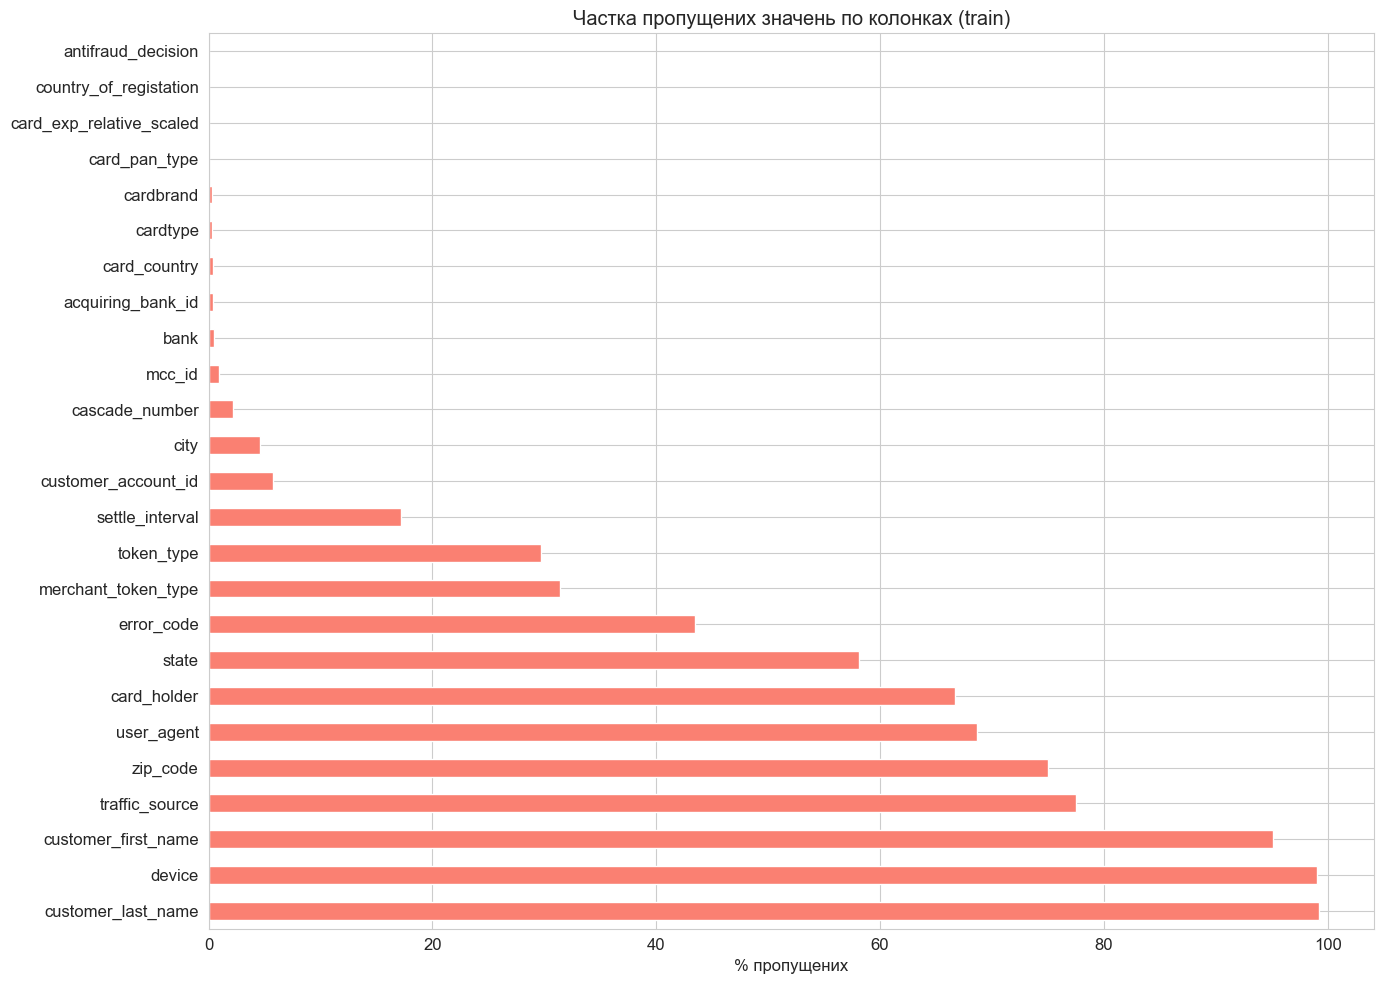

In [7]:
# Візуалізація пропусків
cols_with_missing = missing_df[missing_df['missing_count'] > 0].index.tolist()
if cols_with_missing:
    fig, ax = plt.subplots(figsize=(14, max(5, len(cols_with_missing) * 0.4)))
    missing_df.loc[cols_with_missing, 'missing_pct'].plot.barh(ax=ax, color='salmon')
    ax.set_xlabel('% пропущених')
    ax.set_title('Частка пропущених значень по колонках (train)')
    plt.tight_layout()
    plt.show()
else:
    print("Пропусків немає!")

In [8]:
# Порівняння пропусків train vs test
missing_test = test.isnull().sum()
missing_test_pct = (missing_test / len(test) * 100).round(2)

compare_missing = pd.DataFrame({
    'train_%': missing_train_pct,
    'test_%': missing_test_pct
})
compare_missing[(compare_missing['train_%'] > 0) | (compare_missing['test_%'] > 0)].sort_values('train_%', ascending=False)

,train_%,test_%
customer_last_name,99.18,98.99
device,99.05,99.13
customer_first_name,95.12,95.10
traffic_source,77.48,77.38
zip_code,75.05,74.64
user_agent,68.65,70.27
card_holder,66.71,66.58
state,58.10,57.77
error_code,43.43,44.13
merchant_token_type,31.37,28.95


## 3. Цільова змінна (Target: is_success)

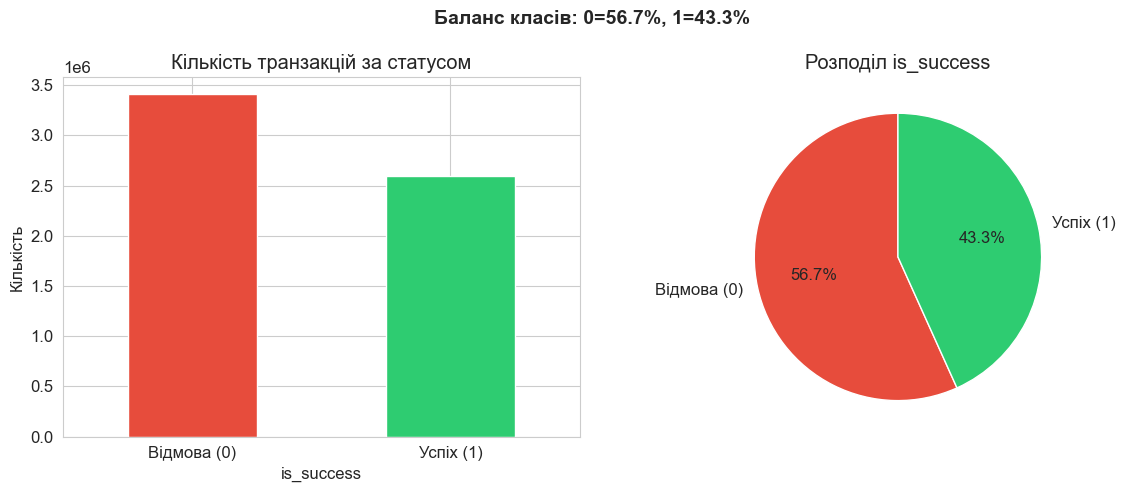


Approval Rate (AR): 43.26%


In [9]:
# Розподіл таргету
target_counts = train['is_success'].value_counts()
target_pct = train['is_success'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts.plot.bar(ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Кількість транзакцій за статусом')
axes[0].set_xlabel('is_success')
axes[0].set_ylabel('Кількість')
axes[0].set_xticklabels(['Відмова (0)', 'Успіх (1)'], rotation=0)

axes[1].pie(target_counts, labels=['Відмова (0)', 'Успіх (1)'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Розподіл is_success')

plt.suptitle(f'Баланс класів: 0={target_pct[0]:.1f}%, 1={target_pct[1]:.1f}%', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nApproval Rate (AR): {target_pct[1]:.2f}%")

## 4. Каскадування (Cascading Analysis)

Solidgate може робити кілька спроб оплати для одного `order_id`. Проаналізуємо ефект каскадування.

Розподіл кількості спроб на замовлення:
psp_order_id
1    5791763
2     103933
3       2044
4         22
Name: count, dtype: int64

Середня кількість спроб: 1.02
Максимальна кількість спроб: 4


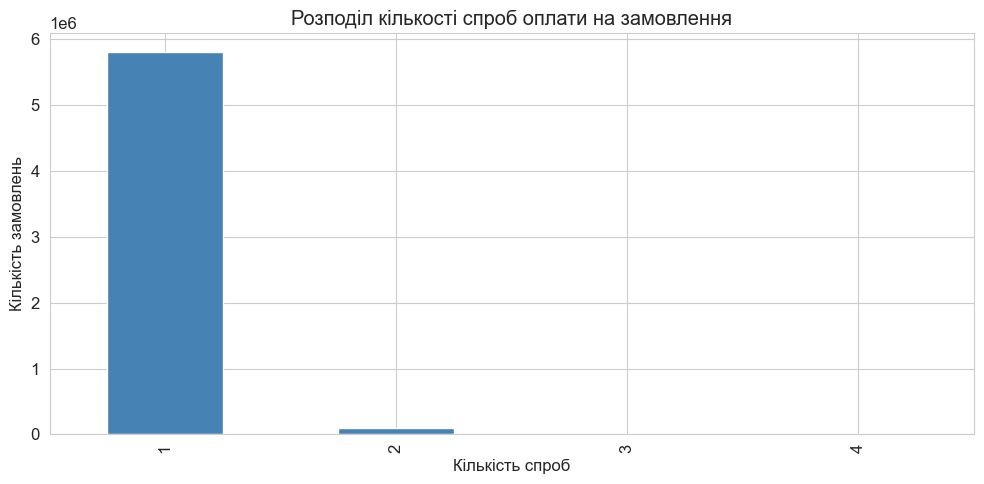

In [10]:
# Кількість спроб на замовлення
attempts_per_order = train.groupby('order_id')['psp_order_id'].count()
print("Розподіл кількості спроб на замовлення:")
print(attempts_per_order.value_counts().sort_index().head(10))
print(f"\nСередня кількість спроб: {attempts_per_order.mean():.2f}")
print(f"Максимальна кількість спроб: {attempts_per_order.max()}")

fig, ax = plt.subplots(figsize=(10, 5))
attempts_per_order.value_counts().sort_index().head(10).plot.bar(ax=ax, color='steelblue')
ax.set_title('Розподіл кількості спроб оплати на замовлення')
ax.set_xlabel('Кількість спроб')
ax.set_ylabel('Кількість замовлень')
plt.tight_layout()
plt.show()

Унікальних customer_account_id: 4,221,797
Середня кількість транзакцій: 1.34
Медіана: 1
Максимум: 578

Розподіл:
count    4.221797e+06
mean     1.340534e+00
std      1.529085e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      5.780000e+02


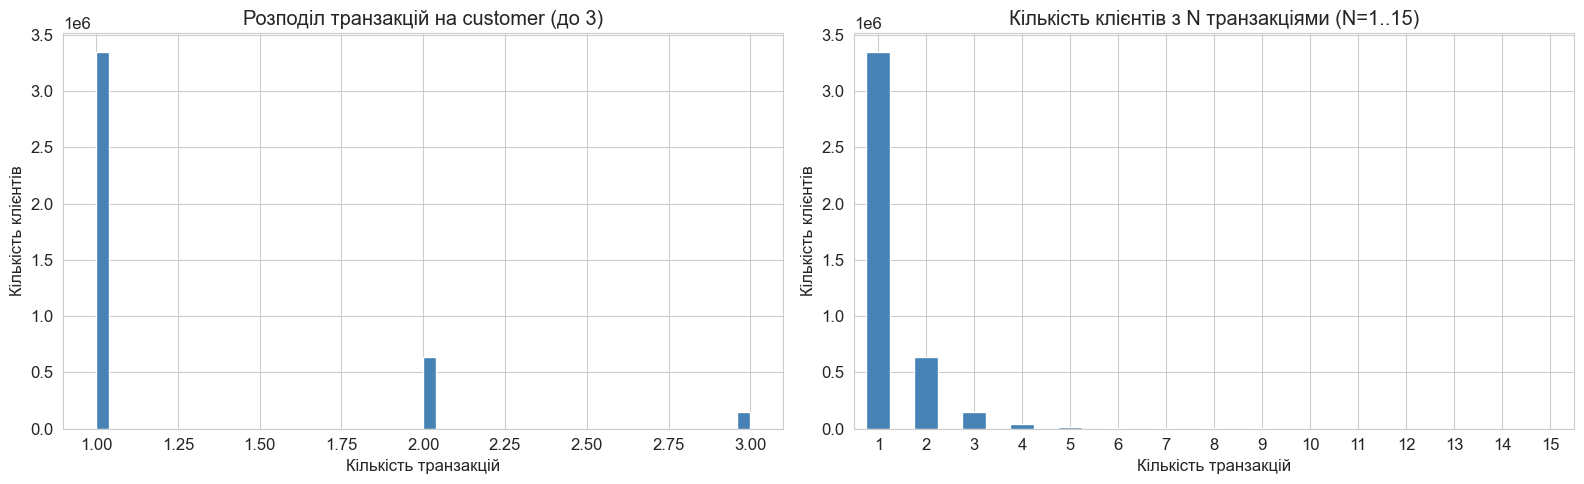

In [69]:
# Розподіл кількості транзакцій на один customer_account_id
txn_per_customer = train.groupby('customer_account_id')['psp_order_id'].count()

print(f"Унікальних customer_account_id: {txn_per_customer.shape[0]:,}")
print(f"Середня кількість транзакцій: {txn_per_customer.mean():.2f}")
print(f"Медіана: {txn_per_customer.median():.0f}")
print(f"Максимум: {txn_per_customer.max()}")
print(f"\nРозподіл:")
print(txn_per_customer.describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Розподіл (обмежимо до 95-го перцентиля для читабельності)
cap = int(txn_per_customer.quantile(0.95))
txn_per_customer[txn_per_customer <= cap].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title(f'Розподіл транзакцій на customer (до {cap})')
axes[0].set_xlabel('Кількість транзакцій')
axes[0].set_ylabel('Кількість клієнтів')

# Top-15 значень
top_counts = txn_per_customer.value_counts().sort_index().head(15)
top_counts.plot.bar(ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Кількість клієнтів з N транзакціями (N=1..15)')
axes[1].set_xlabel('Кількість транзакцій')
axes[1].set_ylabel('Кількість клієнтів')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [71]:
txn_per_customer = train.groupby('customer_account_id')['psp_order_id'].count()
more_than_1 = (txn_per_customer > 1).sum()
total = txn_per_customer.shape[0]
print(f"Клієнтів з більше ніж 1 транзакцією: {more_than_1:,} з {total:,} ({more_than_1/total*100:.2f}%)")

Клієнтів з більше ніж 1 транзакцією: 876,285 з 4,221,797 (20.76%)


                 AR%  Кількість
1 транзакція   52.38    3691897
>1 транзакції  28.71    2313952


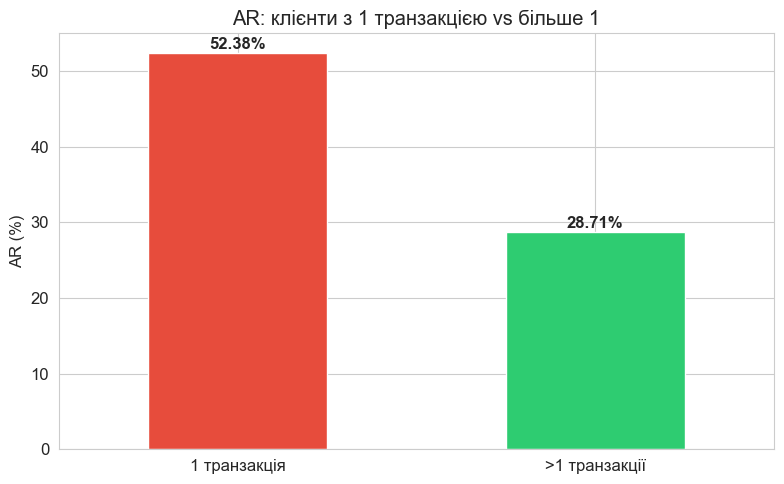

In [75]:
# AR: клієнти з 1 транзакцією vs більше 1
txn_counts = train.groupby('customer_account_id')['psp_order_id'].transform('count')
train['multi_txn'] = (txn_counts > 1).astype(int)

ar_comparison = train.groupby('multi_txn')['is_success'].agg(['mean', 'count'])
ar_comparison.index = ['1 транзакція', '>1 транзакції']
ar_comparison.columns = ['AR', 'Кількість']
ar_comparison['AR%'] = (ar_comparison['AR'] * 100).round(2)
print(ar_comparison[['AR%', 'Кількість']])

fig, ax = plt.subplots(figsize=(8, 5))
ar_comparison['AR%'].plot.bar(ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='white')
ax.set_title('AR: клієнти з 1 транзакцією vs більше 1')
ax.set_ylabel('AR (%)')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(ar_comparison['AR%']):
    ax.text(i, v + 0.5, f'{v:.2f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

train.drop(columns=['multi_txn'], inplace=True)

## Аналіз зміни ip_country для кожного customer_account_id

Юзерів з >1 TX: 876,285
Юзерів, у яких ip_country змінювалась хоча б раз: 7,561 (0.86%)
Транзакцій зі зміною ip_country: 8,587 (0.37%)


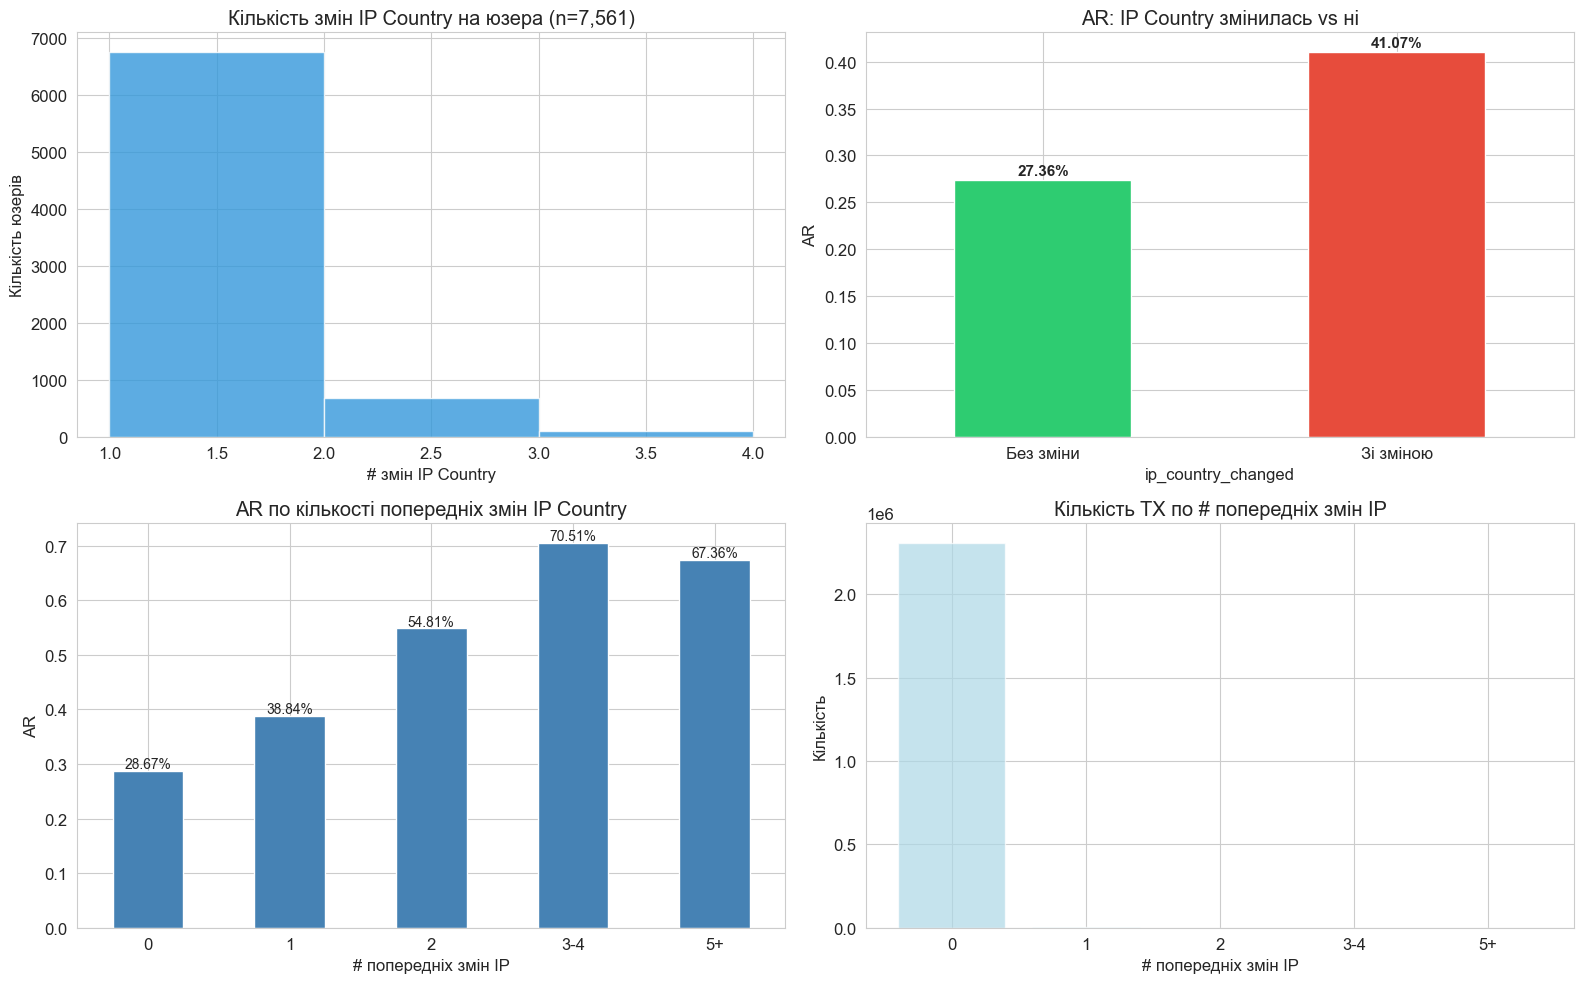


AR (без зміни IP):  27.36%
AR (зі зміною IP): 41.07%


In [ ]:
# Аналіз зміни ip_country для кожного customer_account_id
# Враховуємо лише юзерів з >1 транзакцією
train['order_created_at'] = pd.to_datetime(train['order_created_at'])
test['order_created_at'] = pd.to_datetime(test['order_created_at'])


df_sorted = train.dropna(subset=['customer_account_id']).sort_values(['customer_account_id', 'order_created_at']).copy()

# Попередня ip_country та час попередньої TX
df_sorted['prev_ip_country'] = df_sorted.groupby('customer_account_id')['ip_country'].shift(1)
df_sorted['prev_time'] = df_sorted.groupby('customer_account_id')['order_created_at'].shift(1)

df_sorted['ip_country_changed'] = (
    df_sorted['prev_ip_country'].notna() &
    (df_sorted['ip_country'] != df_sorted['prev_ip_country'])
).astype(int)

# Кумулятивна кількість змін ip_country до поточної TX
df_sorted['prior_ip_changes'] = df_sorted.groupby('customer_account_id')['ip_country_changed'].cumsum() - df_sorted['ip_country_changed']

# Фільтруємо юзерів з >1 TX
user_tx_counts = df_sorted.groupby('customer_account_id')['psp_order_id'].transform('count')
multi_tx = df_sorted[user_tx_counts > 1].copy()

# Юзери з хоча б 1 зміною
users_with_change = multi_tx[multi_tx['ip_country_changed'] == 1]['customer_account_id'].unique()

print(f"Юзерів з >1 TX: {multi_tx['customer_account_id'].nunique():,}")
print(f"Юзерів, у яких ip_country змінювалась хоча б раз: {len(users_with_change):,} "
      f"({len(users_with_change) / multi_tx['customer_account_id'].nunique():.2%})")
print(f"Транзакцій зі зміною ip_country: {multi_tx['ip_country_changed'].sum():,} "
      f"({multi_tx['ip_country_changed'].mean():.2%})")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Кількість змін ip_country на юзера
changes_per_user = multi_tx.groupby('customer_account_id')['ip_country_changed'].sum()
changes_per_user_nonzero = changes_per_user[changes_per_user > 0]
axes[0, 0].hist(changes_per_user_nonzero, bins=range(1, int(changes_per_user_nonzero.quantile(0.99)) + 2),
                color='#3498db', edgecolor='white', alpha=0.8)
axes[0, 0].set_title(f'Кількість змін IP Country на юзера (n={len(changes_per_user_nonzero):,})')
axes[0, 0].set_xlabel('# змін IP Country')
axes[0, 0].set_ylabel('Кількість юзерів')

# 2. Fail rate: TX зі зміною ip_country vs без
has_prev = multi_tx[multi_tx['prev_ip_country'].notna()]
ar_change = has_prev.groupby('ip_country_changed')['is_success'].mean()
ar_change.plot(kind='bar', ax=axes[0, 1], color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0, 1].set_xticklabels(['Без зміни', 'Зі зміною'], rotation=0)
axes[0, 1].set_title('AR: IP Country змінилась vs ні')
axes[0, 1].set_ylabel('AR')
for i, v in enumerate(ar_change):
    axes[0, 1].text(i, v + 0.005, f'{v:.2%}', ha='center', fontsize=11, fontweight='bold')

# 3. AR по кількості попередніх змін ip_country
bins_ch = [0, 1, 2, 3, 5, 100]
labels_ch = ['0', '1', '2', '3-4', '5+']
multi_tx['prior_ip_changes_bin'] = pd.cut(multi_tx['prior_ip_changes'], bins=bins_ch, labels=labels_ch, right=False)
ar_by_changes = multi_tx.groupby('prior_ip_changes_bin', observed=False)['is_success'].mean()
ar_by_changes.plot(kind='bar', ax=axes[1, 0], color='steelblue', edgecolor='white')
axes[1, 0].set_title('AR по кількості попередніх змін IP Country')
axes[1, 0].set_xlabel('# попередніх змін IP')
axes[1, 0].set_ylabel('AR')
axes[1, 0].tick_params(axis='x', rotation=0)
for i, v in enumerate(ar_by_changes):
    axes[1, 0].text(i, v + 0.005, f'{v:.2%}', ha='center', fontsize=10)

# 4. Fail rate по кількості попередніх змін
fail_by_changes = multi_tx.groupby('prior_ip_changes_bin', observed=False)['is_success'].agg(['mean', 'count'])
fail_by_changes.columns = ['AR', 'Count']
axes[1, 1].bar(range(len(fail_by_changes)), fail_by_changes['Count'], color='lightblue', alpha=0.7)
axes[1, 1].set_xticks(range(len(fail_by_changes)))
axes[1, 1].set_xticklabels(labels_ch)
axes[1, 1].set_title('Кількість TX по # попередніх змін IP')
axes[1, 1].set_xlabel('# попередніх змін IP')
axes[1, 1].set_ylabel('Кількість')

plt.tight_layout()
plt.show()

print(f"\nAR (без зміни IP):  {ar_change.get(0, 0):.2%}")
print(f"AR (зі зміною IP): {ar_change.get(1, 0):.2%}")

Транзакцій зі зміною IP Country: 8,587

Час між зміною IP (години):
count    8587.000000
mean      287.393427
std       292.318202
min         0.000278
25%        24.234861
50%       194.614722
75%       461.500972
max      1263.967222


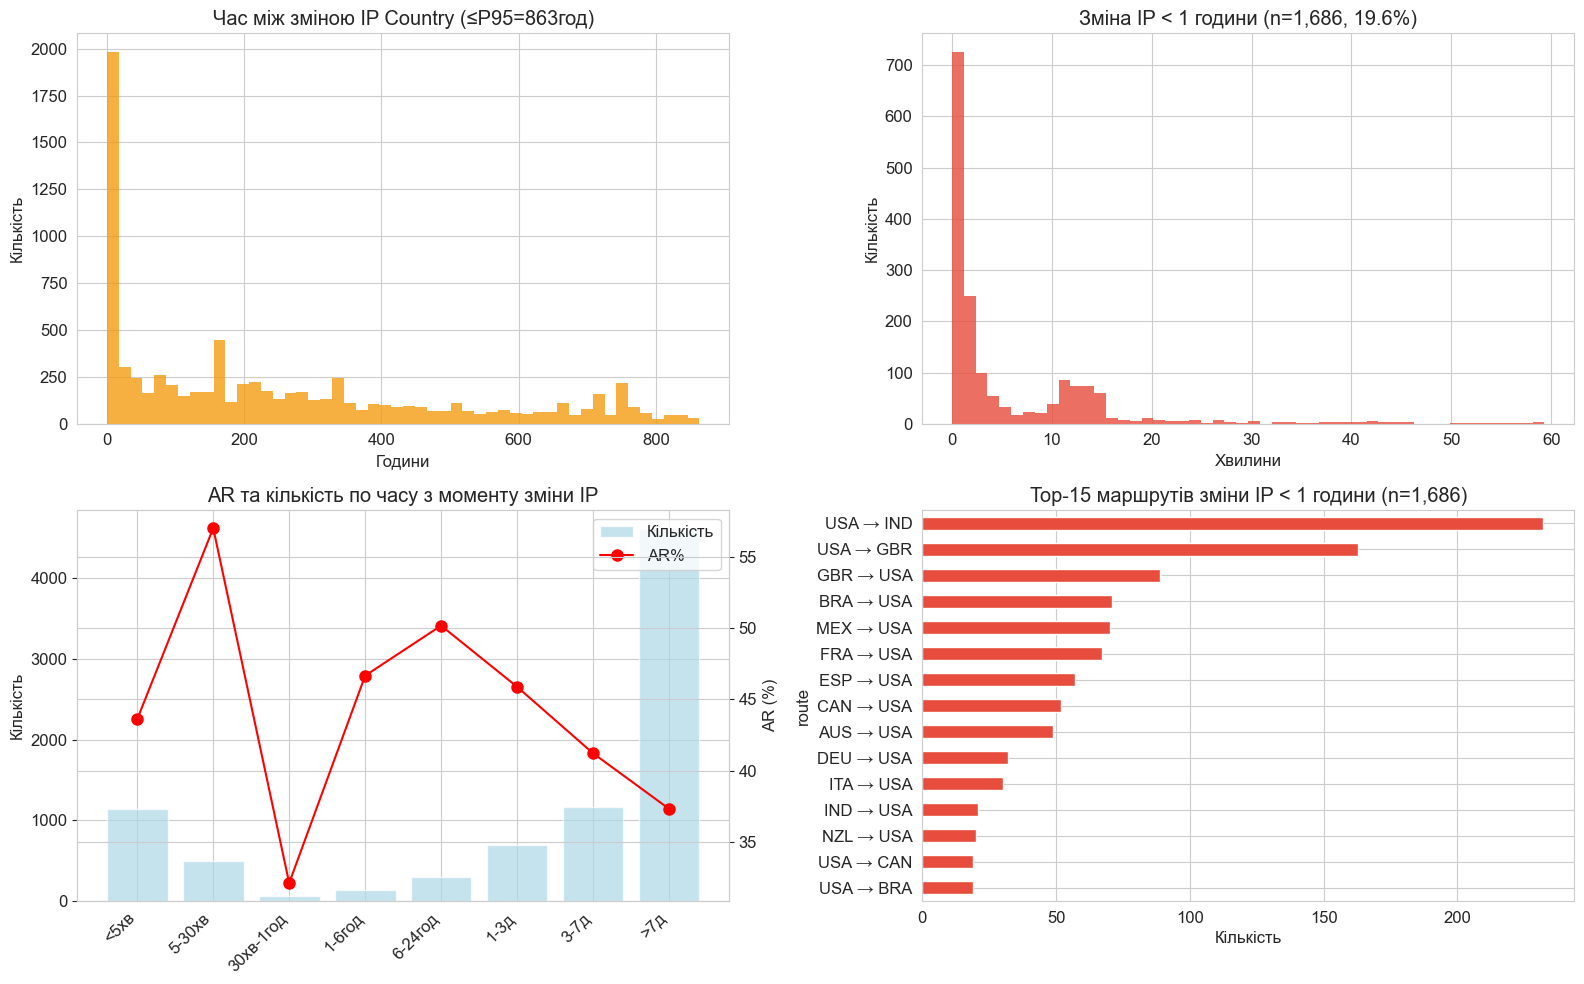


=== Impossible Travel (зміна IP < 1 години) ===
Таких транзакцій: 1,686 (19.6% від усіх змін IP)
AR серед них: 47.15%
AR серед змін IP ≥ 1 години: 39.59%

=== Зміна IP < 5 хвилин ===
Таких транзакцій: 1,137
AR серед них: 43.62%
Це скоріше VPN/проксі, ніж реальна подорож


In [3]:
# Час між зміною IP Country та оцінка "impossible travel"

df_changed = df_sorted[df_sorted['ip_country_changed'] == 1].copy()
df_changed['time_diff_hours'] = (df_changed['order_created_at'] - df_changed['prev_time']).dt.total_seconds() / 3600

print(f"Транзакцій зі зміною IP Country: {len(df_changed):,}")
print(f"\nЧас між зміною IP (години):")
print(df_changed['time_diff_hours'].describe().to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Розподіл часу між змінами IP (до P95)
p95 = df_changed['time_diff_hours'].quantile(0.95)
filtered = df_changed[df_changed['time_diff_hours'] <= p95]['time_diff_hours']
axes[0, 0].hist(filtered, bins=50, color='#f39c12', edgecolor='none', alpha=0.8)
axes[0, 0].set_title(f'Час між зміною IP Country (≤P95={p95:.0f}год)')
axes[0, 0].set_xlabel('Години')
axes[0, 0].set_ylabel('Кількість')

# 2. Розподіл часу < 1 години (потенційно підозрілі — VPN/проксі)
very_fast = df_changed[df_changed['time_diff_hours'] < 1]['time_diff_hours'] * 60  # хвилини
axes[0, 1].hist(very_fast, bins=50, color='#e74c3c', edgecolor='none', alpha=0.8)
axes[0, 1].set_title(f'Зміна IP < 1 години (n={len(very_fast):,}, {len(very_fast)/len(df_changed):.1%})')
axes[0, 1].set_xlabel('Хвилини')
axes[0, 1].set_ylabel('Кількість')

# 3. AR по бінах часу з моменту зміни IP
time_bins = [0, 0.0833, 0.5, 1, 6, 24, 72, 168, float('inf')]
time_labels = ['<5хв', '5-30хв', '30хв-1год', '1-6год', '6-24год', '1-3д', '3-7д', '>7д']
df_changed['time_bin'] = pd.cut(df_changed['time_diff_hours'], bins=time_bins, labels=time_labels, right=False)
ar_by_time = df_changed.groupby('time_bin', observed=False)['is_success'].agg(['mean', 'count'])

ax3 = axes[1, 0]
ax3_twin = ax3.twinx()
ax3.bar(range(len(ar_by_time)), ar_by_time['count'], color='lightblue', alpha=0.7, label='Кількість')
ax3_twin.plot(range(len(ar_by_time)), ar_by_time['mean'] * 100, 'ro-', markersize=8, label='AR%')
ax3.set_xticks(range(len(ar_by_time)))
ax3.set_xticklabels(time_labels, rotation=45, ha='right')
ax3.set_title('AR та кількість по часу з моменту зміни IP')
ax3.set_ylabel('Кількість')
ax3_twin.set_ylabel('AR (%)')
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# 4. Top пар країн при швидкій зміні (<1 години) — "impossible travel"
fast_changes = df_changed[df_changed['time_diff_hours'] < 1].copy()
if len(fast_changes) > 0:
    fast_changes['route'] = fast_changes['prev_ip_country'] + ' → ' + fast_changes['ip_country']
    top_routes = fast_changes['route'].value_counts().head(15)
    top_routes.plot.barh(ax=axes[1, 1], color='#e74c3c', edgecolor='white')
    axes[1, 1].set_title(f'Top-15 маршрутів зміни IP < 1 години (n={len(fast_changes):,})')
    axes[1, 1].set_xlabel('Кількість')
    axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

# Статистика
print(f"\n=== Impossible Travel (зміна IP < 1 години) ===")
print(f"Таких транзакцій: {len(fast_changes):,} ({len(fast_changes)/len(df_changed):.1%} від усіх змін IP)")
print(f"AR серед них: {fast_changes['is_success'].mean():.2%}")
print(f"AR серед змін IP ≥ 1 години: {df_changed[df_changed['time_diff_hours'] >= 1]['is_success'].mean():.2%}")

very_fast_5min = df_changed[df_changed['time_diff_hours'] < 0.0833]
print(f"\n=== Зміна IP < 5 хвилин ===")
print(f"Таких транзакцій: {len(very_fast_5min):,}")
if len(very_fast_5min) > 0:
    print(f"AR серед них: {very_fast_5min['is_success'].mean():.2%}")
    print(f"Це скоріше VPN/проксі, ніж реальна подорож")

In [74]:
txn_per_customer['is_success_mean'].mean()

np.float64(0.27375171673225956)

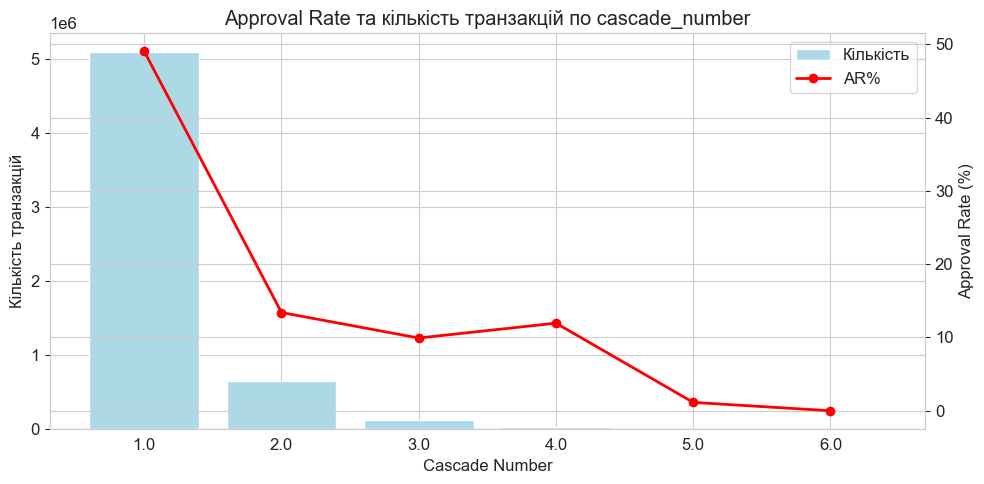

 cascade_number  approval_rate   count
            1.0       0.490618 5090700
            2.0       0.134094  644143
            3.0       0.099286  120410
            4.0       0.119568   17697
            5.0       0.011419     613
            6.0       0.000000       2


In [11]:
# AR по cascade_number
cascade_ar = train.groupby('cascade_number')['is_success'].agg(['mean', 'count']).reset_index()
cascade_ar.columns = ['cascade_number', 'approval_rate', 'count']

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(cascade_ar['cascade_number'].astype(str), cascade_ar['count'], color='lightblue', label='Кількість')
ax2.plot(cascade_ar['cascade_number'].astype(str), cascade_ar['approval_rate'] * 100, 'ro-', linewidth=2, label='AR%')

ax1.set_xlabel('Cascade Number')
ax1.set_ylabel('Кількість транзакцій')
ax2.set_ylabel('Approval Rate (%)')
ax1.set_title('Approval Rate та кількість транзакцій по cascade_number')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

print(cascade_ar.to_string(index=False))

## 5. Числові ознаки

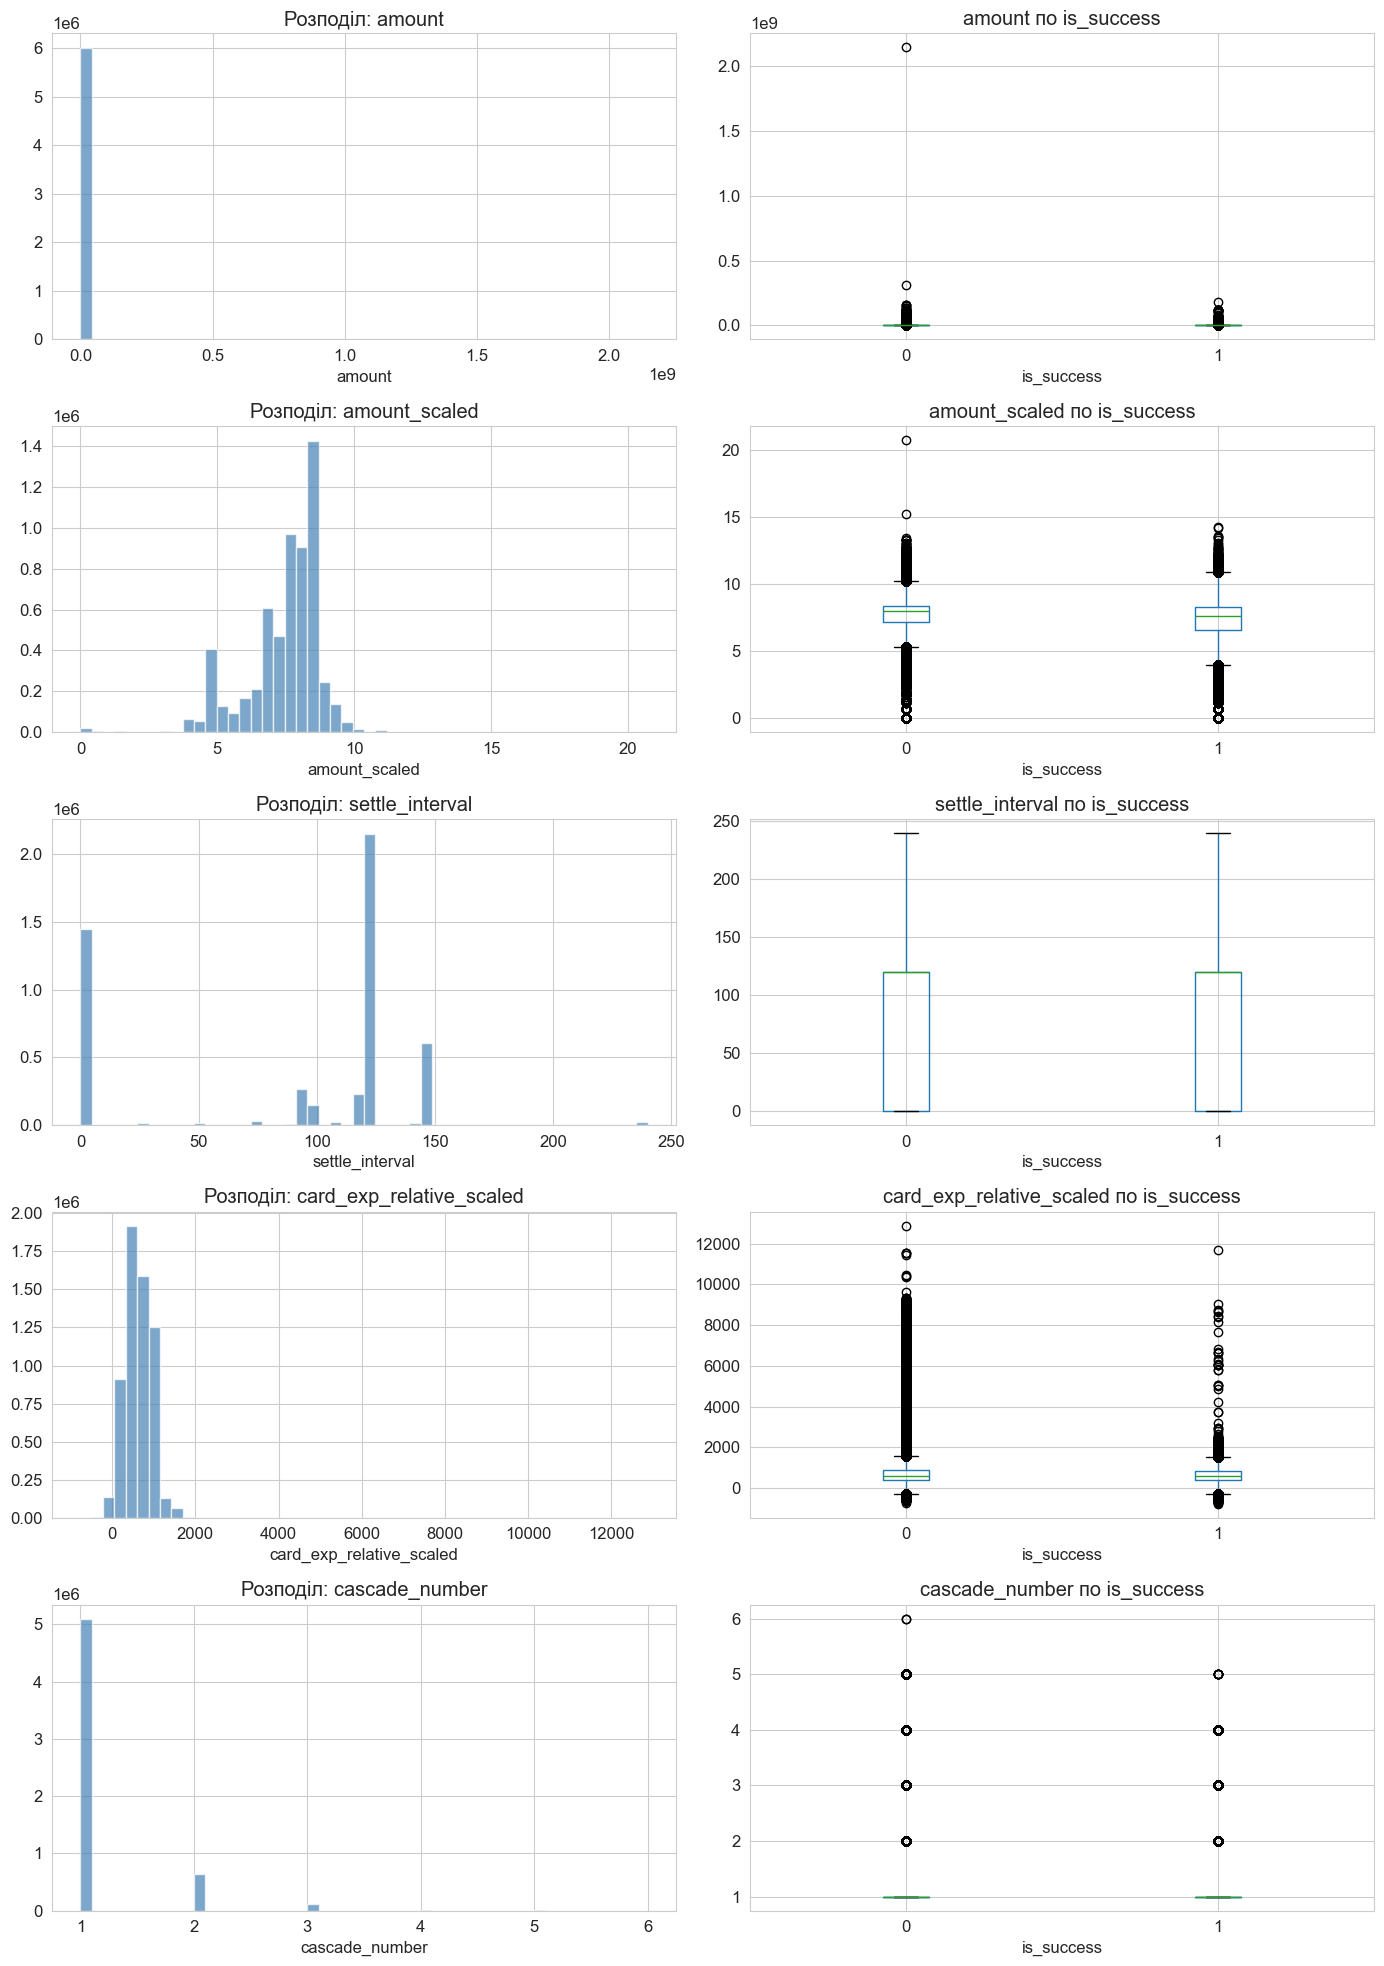

In [12]:
# Розподіл числових ознак
numeric_features = ['amount', 'amount_scaled', 'settle_interval', 'card_exp_relative_scaled', 'cascade_number']
existing_numeric = [c for c in numeric_features if c in train.columns]

fig, axes = plt.subplots(len(existing_numeric), 2, figsize=(14, 4 * len(existing_numeric)))
if len(existing_numeric) == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(existing_numeric):
    # Розподіл
    train[col].dropna().hist(bins=50, ax=axes[i, 0], color='steelblue', alpha=0.7)
    axes[i, 0].set_title(f'Розподіл: {col}')
    axes[i, 0].set_xlabel(col)

    # Boxplot по таргету
    train.boxplot(column=col, by='is_success', ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} по is_success')
    axes[i, 1].set_xlabel('is_success')

plt.suptitle('')
plt.tight_layout()
plt.show()

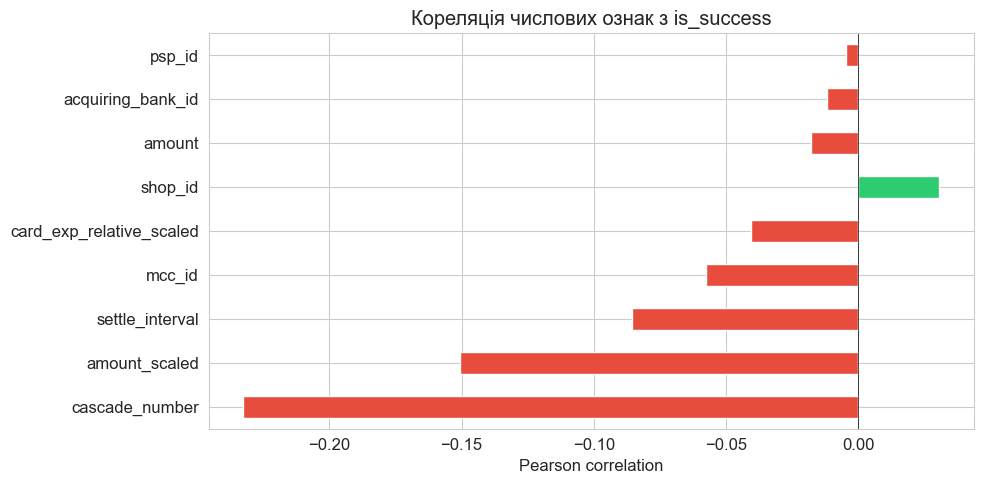

In [13]:
# Кореляція числових ознак з таргетом
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
if 'is_success' in numeric_cols:
    corr_with_target = train[numeric_cols].corr()['is_success'].drop('is_success').sort_values(key=abs, ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, max(5, len(corr_with_target) * 0.3)))
    corr_with_target.plot.barh(ax=ax, color=corr_with_target.apply(lambda x: '#2ecc71' if x > 0 else '#e74c3c'))
    ax.set_title('Кореляція числових ознак з is_success')
    ax.set_xlabel('Pearson correlation')
    ax.axvline(x=0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

In [ ]:
train

## 6. Категоріальні ознаки та AR

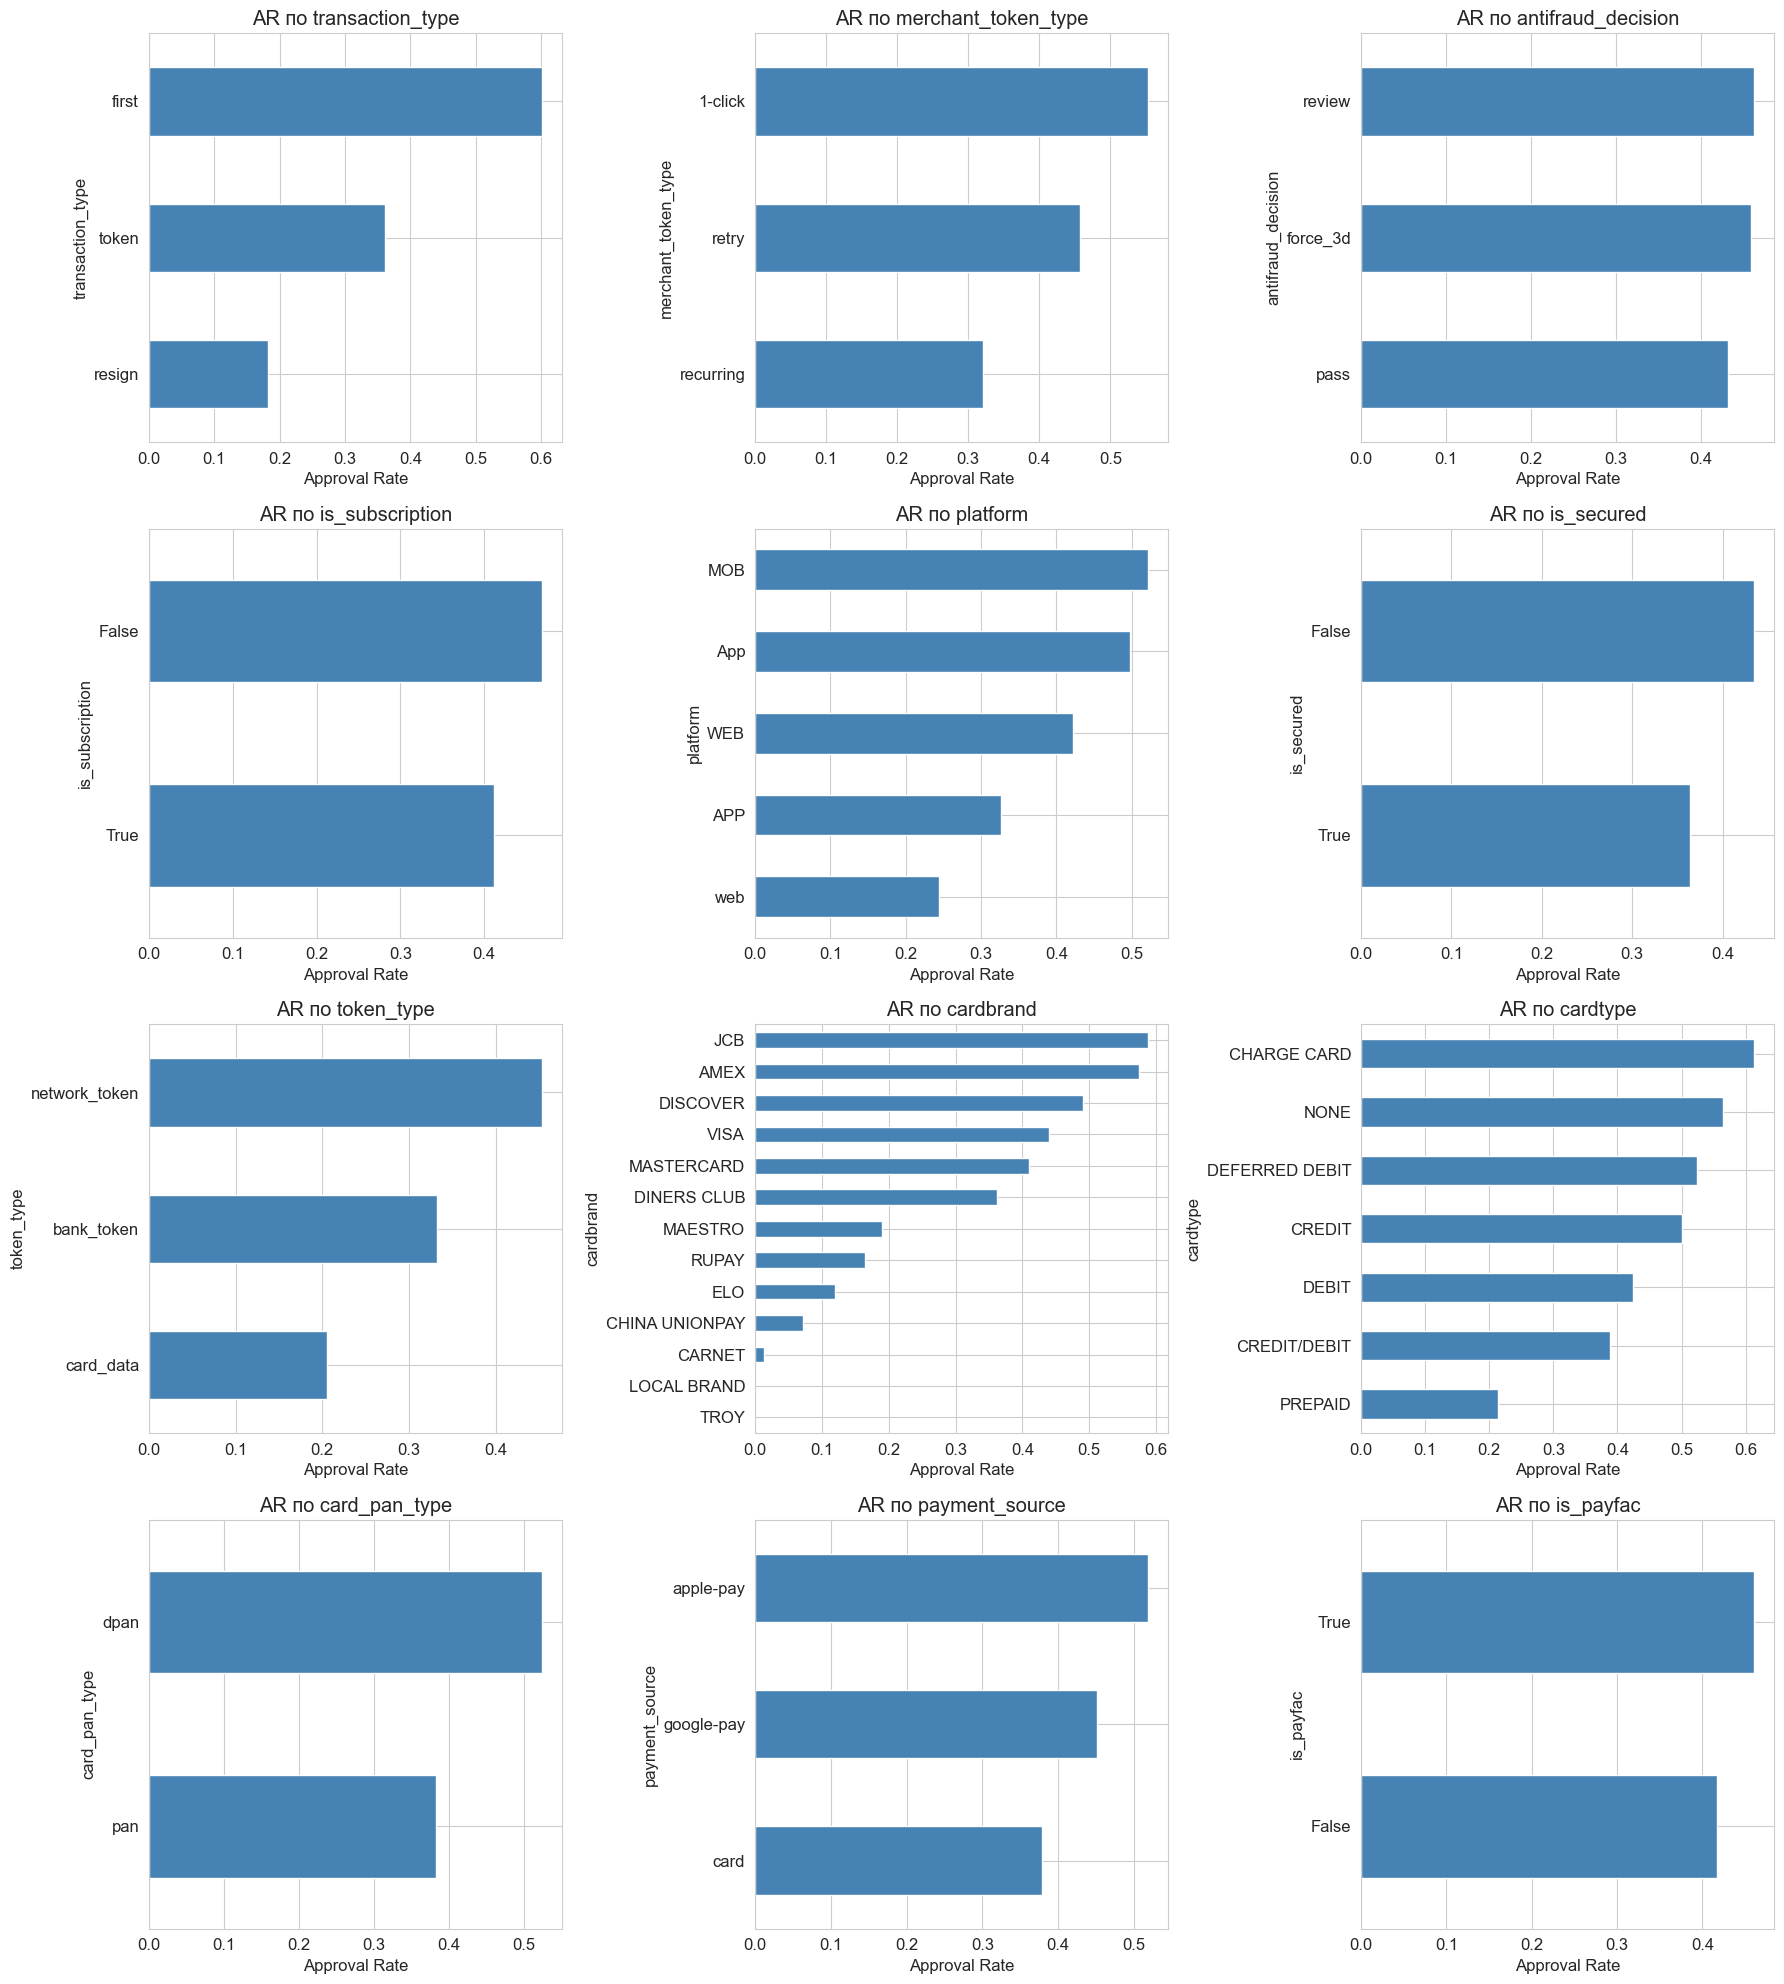

In [14]:
# AR по основних категоріальних ознаках
cat_features = [
    'transaction_type', 'merchant_token_type', 'antifraud_decision',
    'is_subscription', 'platform', 'is_secured', 'token_type',
    'cardbrand', 'cardtype', 'card_pan_type', 'payment_source', 'is_payfac'
]
cat_features = [c for c in cat_features if c in train.columns]

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    if i >= len(axes):
        break
    ar_by_cat = train.groupby(col)['is_success'].agg(['mean', 'count']).sort_values('mean', ascending=True)
    ar_by_cat = ar_by_cat[ar_by_cat['count'] >= 100]  # мінімум 100 транзакцій
    
    if len(ar_by_cat) > 15:
        ar_by_cat = ar_by_cat.tail(15)
    
    ar_by_cat['mean'].plot.barh(ax=axes[i], color='steelblue')
    axes[i].set_title(f'AR по {col}')
    axes[i].set_xlabel('Approval Rate')

# Прибрати пусті графіки
for j in range(len(cat_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [34]:
train[train['cardbrand'] == 'TROY']['is_success'].value_counts()

is_success
0    747
Name: count, dtype: int64

In [ ]:
train[train['cardbrand'] == 'TROY']['is_success'].value_counts()

In [ ]:
train[train['cardbrand'] == 'TROY']['is_success'].value_counts()

In [15]:
# Кардинальність категоріальних ознак
all_cat_cols = train.select_dtypes(include=['object', 'bool']).columns.tolist()
cardinality = pd.DataFrame({
    'column': all_cat_cols,
    'nunique_train': [train[c].nunique() for c in all_cat_cols],
    'nunique_test': [test[c].nunique() if c in test.columns else None for c in all_cat_cols],
}).sort_values('nunique_train', ascending=False)

print("Кардинальність категоріальних ознак:")
cardinality

Кардинальність категоріальних ознак:


,column,nunique_train,nunique_test
0,psp_order_id,6005849,667317
1,order_id,5897762,655601
2,customer_account_id,4221797,560037
3,order_created_at,2944991,315572
27,card_holder,1251967,178271
20,user_agent,201920,24327
16,zip_code,85293,32950
18,city,62258,29102
13,customer_first_name,52799,10940
14,customer_last_name,18752,4360


## 7. Часовий аналіз (Temporal Analysis)

In [16]:
train['order_created_at'] = pd.to_datetime(train['order_created_at'])
test['order_created_at'] = pd.to_datetime(test['order_created_at'])

print(f"Train period: {train['order_created_at'].min()} — {train['order_created_at'].max()}")
print(f"Test period:  {test['order_created_at'].min()} — {test['order_created_at'].max()}")

# Часові ознаки
train['hour'] = train['order_created_at'].dt.hour
train['dayofweek'] = train['order_created_at'].dt.dayofweek
train['day'] = train['order_created_at'].dt.day
train['date'] = train['order_created_at'].dt.date

Train period: 2026-01-01 00:00:01 — 2026-02-23 09:15:48
Test period:  2026-02-23 09:15:51 — 2026-02-28 23:59:59


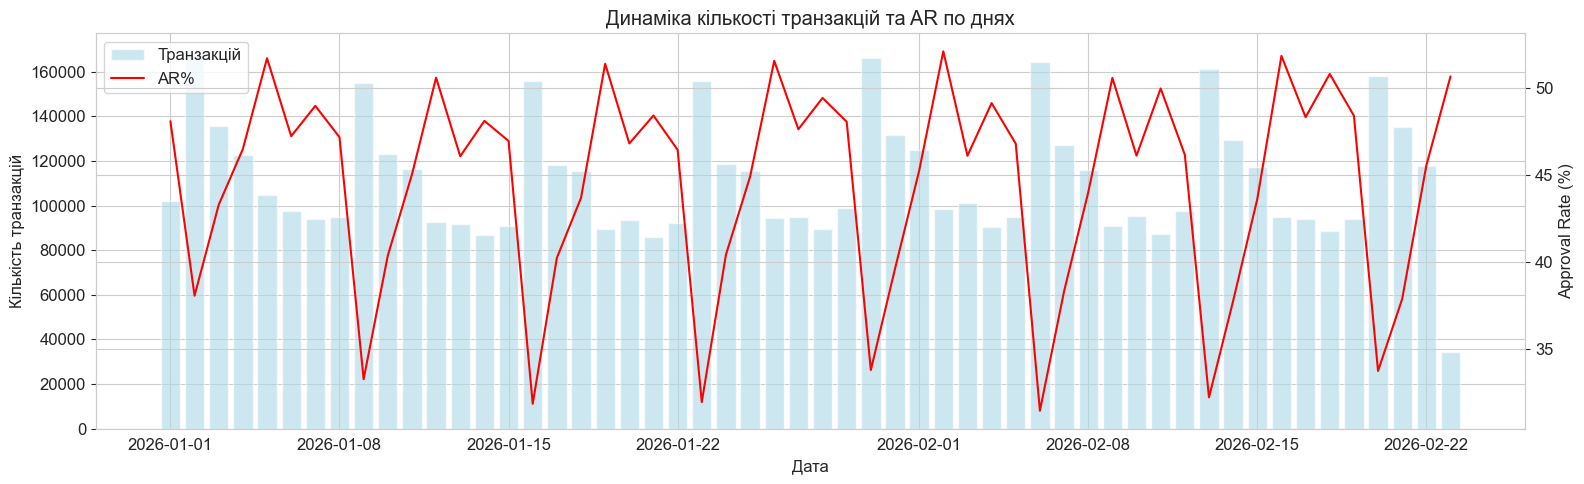

In [17]:
# AR по датам
daily_stats = train.groupby('date').agg(
    transactions=('is_success', 'count'),
    ar=('is_success', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.bar(daily_stats['date'], daily_stats['transactions'], color='lightblue', alpha=0.6, label='Транзакцій')
ax2.plot(daily_stats['date'], daily_stats['ar'] * 100, 'r-', linewidth=1.5, label='AR%')

ax1.set_xlabel('Дата')
ax1.set_ylabel('Кількість транзакцій')
ax2.set_ylabel('Approval Rate (%)')
ax1.set_title('Динаміка кількості транзакцій та AR по днях')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [44]:
train['date'].max()

datetime.date(2026, 2, 23)

In [45]:
train['date'].min()

datetime.date(2026, 1, 1)

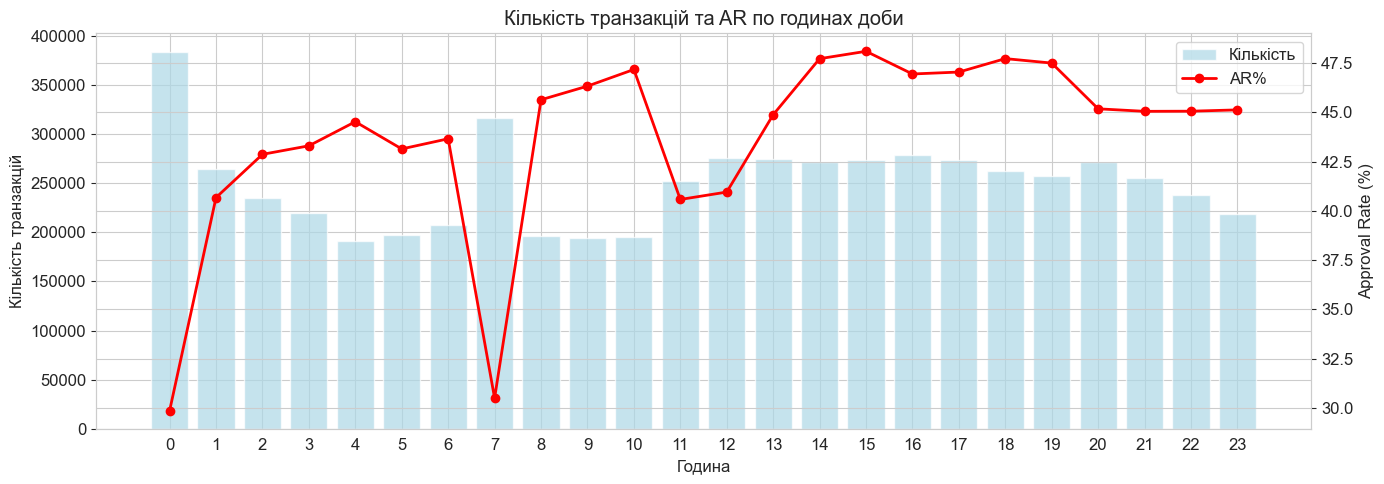

In [49]:
# Розподіл по годинах: кількість транзакцій та AR
hourly_stats = train.groupby('hour')['is_success'].agg(['count', 'mean']).reset_index()
hourly_stats['mean'] *= 100

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(hourly_stats['hour'], hourly_stats['count'], color='lightblue', alpha=0.7, label='Кількість')
ax2.plot(hourly_stats['hour'], hourly_stats['mean'], 'ro-', linewidth=2, markersize=6, label='AR%')

ax1.set_xlabel('Година')
ax1.set_ylabel('Кількість транзакцій')
ax2.set_ylabel('Approval Rate (%)')
ax1.set_title('Кількість транзакцій та AR по годинах доби')
ax1.set_xticks(range(0, 24))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

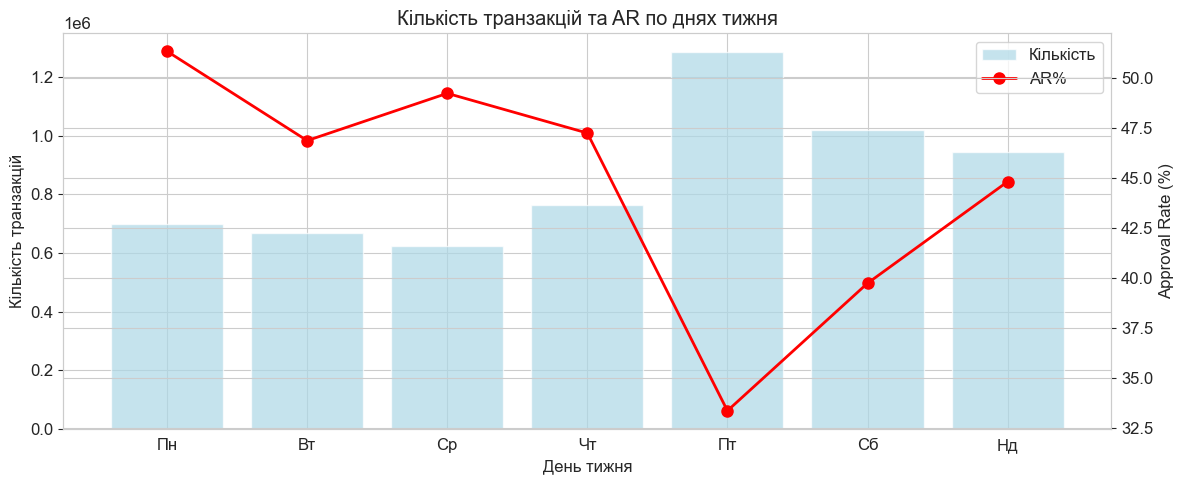

In [48]:
# Розподіл по днях тижня: кількість транзакцій та AR
dow_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Нд']

dow_stats = train.groupby('dayofweek')['is_success'].agg(['count', 'mean']).reset_index()
dow_stats['mean'] *= 100
dow_stats['dayofweek'] = dow_names

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(dow_stats['dayofweek'], dow_stats['count'], color='lightblue', alpha=0.7, label='Кількість')
ax2.plot(dow_stats['dayofweek'], dow_stats['mean'], 'ro-', linewidth=2, markersize=8, label='AR%')

ax1.set_xlabel('День тижня')
ax1.set_ylabel('Кількість транзакцій')
ax2.set_ylabel('Approval Rate (%)')
ax1.set_title('Кількість транзакцій та AR по днях тижня')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()


## 8. Географічний аналіз

In [ ]:
# Top-20 країн по кількості транзакцій та AR
country_stats = train.groupby('ip_country')['is_success'].agg(['mean', 'count']).reset_index()
country_stats.columns = ['country', 'ar', 'count']
top_countries = country_stats.nlargest(20, 'count')

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

x = range(len(top_countries))
ax1.bar(x, top_countries['count'], color='lightblue', alpha=0.7, label='Кількість')
ax2.plot(x, top_countries['ar'] * 100, 'ro-', markersize=8, label='AR%')

ax1.set_xticks(x)
ax1.set_xticklabels(top_countries['country'], rotation=45, ha='right')
ax1.set_ylabel('Кількість транзакцій')
ax2.set_ylabel('AR (%)')
ax1.set_title('Top-20 країн: кількість транзакцій та AR')
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.show()

In [20]:
# Cross-border: ip_country vs card_country
train['is_cross_border'] = (train['ip_country'] != train['card_country']).astype(int)
cb_ar = train.groupby('is_cross_border')['is_success'].agg(['mean', 'count'])
cb_ar.columns = ['AR', 'Count']
cb_ar.index = ['Domestic', 'Cross-border']
print("AR для domestic vs cross-border транзакцій:")
print(cb_ar)
print(f"\nЧастка cross-border: {train['is_cross_border'].mean()*100:.1f}%")

AR для domestic vs cross-border транзакцій:
                    AR    Count
Domestic      0.433459  5651679
Cross-border  0.418638   354170

Частка cross-border: 5.9%


## 9. Аналіз error_code

In [21]:
# Top error codes
error_stats = train.groupby('error_code').agg(
    count=('is_success', 'count'),
    ar=('is_success', 'mean')
).sort_values('count', ascending=False)

print(f"Унікальних error_code: {train['error_code'].nunique()}")
print(f"Пропущених error_code: {train['error_code'].isna().sum()} ({train['error_code'].isna().mean()*100:.1f}%)")
print(f"\nTop-15 error codes:")
error_stats.head(15)

Унікальних error_code: 66
Пропущених error_code: 2608484 (43.4%)

Top-15 error codes:


,count,ar
error_code,,
3.02,802808,0.0
3.08,715749,0.0
3.10,580793,0.0
3.02.2,248228,0.0
3.04,148409,0.0
7.03.1,132284,0.0
3.12,117117,0.0
4.03,78941,0.0
2.08,72995,0.0


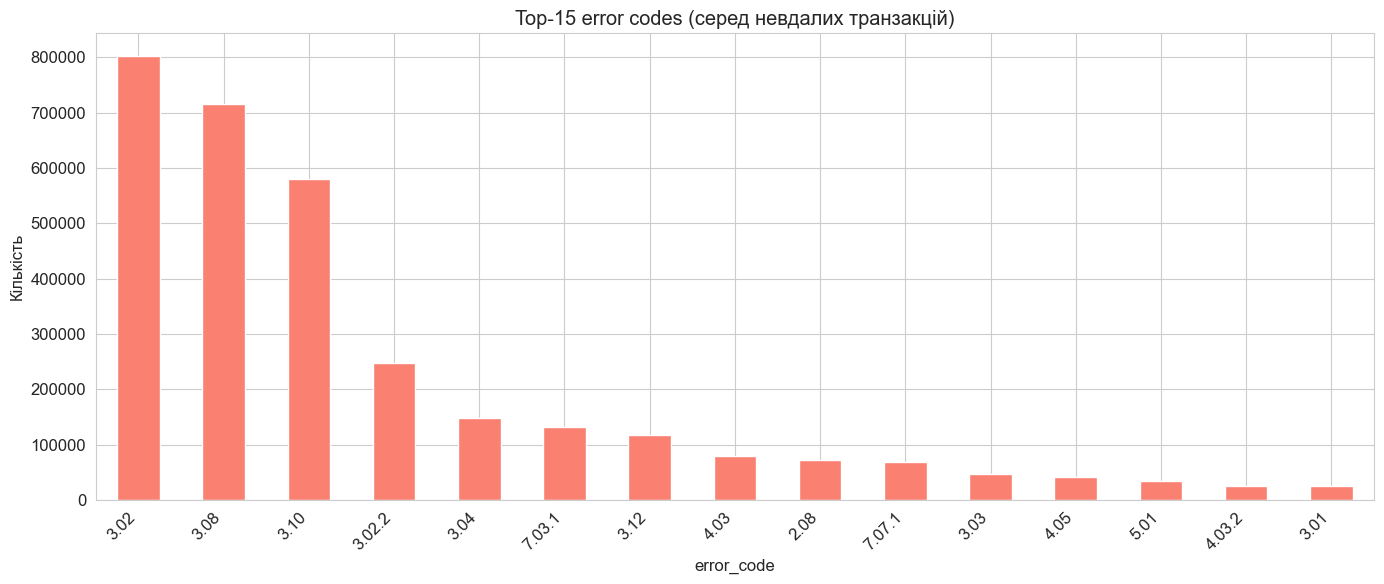

In [22]:
# Візуалізація top error codes (тільки з is_success=0)
failed = train[train['is_success'] == 0]
top_errors = failed['error_code'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 6))
top_errors.plot.bar(ax=ax, color='salmon')
ax.set_title('Top-15 error codes (серед невдалих транзакцій)')
ax.set_ylabel('Кількість')
ax.set_xlabel('error_code')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Провайдери та MID аналіз

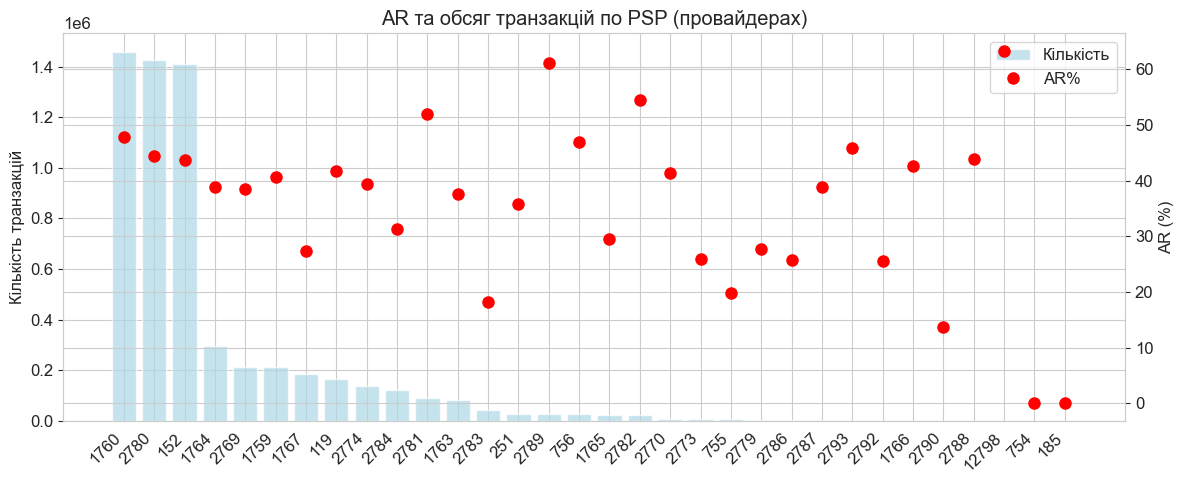

Унікальних PSP: 32
Унікальних acquiring_bank_id: 64


In [23]:
# AR по psp_id
psp_stats = train.groupby('psp_id')['is_success'].agg(['mean', 'count']).sort_values('count', ascending=False)
psp_stats.columns = ['ar', 'count']

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

x = range(len(psp_stats))
ax1.bar(x, psp_stats['count'], color='lightblue', alpha=0.7, label='Кількість')
ax2.plot(x, psp_stats['ar'] * 100, 'ro', markersize=8, label='AR%')

ax1.set_xticks(x)
ax1.set_xticklabels(psp_stats.index, rotation=45, ha='right')
ax1.set_ylabel('Кількість транзакцій')
ax2.set_ylabel('AR (%)')
ax1.set_title('AR та обсяг транзакцій по PSP (провайдерах)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.show()

print(f"Унікальних PSP: {train['psp_id'].nunique()}")
print(f"Унікальних acquiring_bank_id: {train['acquiring_bank_id'].nunique()}")

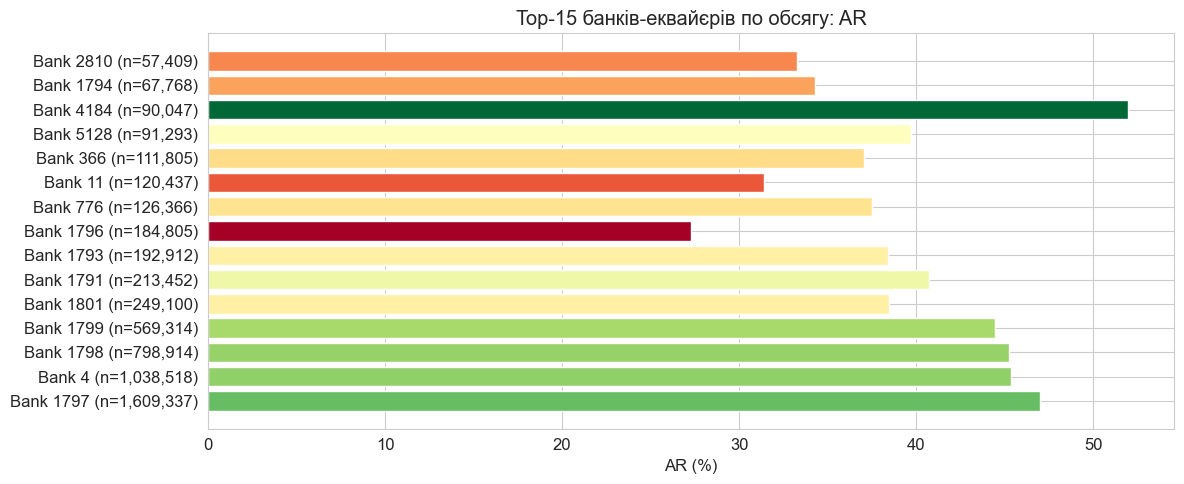

In [24]:
# AR по top acquiring banks
acq_stats = train.groupby('acquiring_bank_id')['is_success'].agg(['mean', 'count']).sort_values('count', ascending=False)
acq_stats.columns = ['ar', 'count']
top_acq = acq_stats.head(15)

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.RdYlGn((top_acq['ar'] - top_acq['ar'].min()) / (top_acq['ar'].max() - top_acq['ar'].min()))
ax.barh(range(len(top_acq)), top_acq['ar'] * 100, color=colors)
ax.set_yticks(range(len(top_acq)))
ax.set_yticklabels([f"Bank {int(b)} (n={int(c):,})" for b, c in zip(top_acq.index, top_acq['count'])])
ax.set_xlabel('AR (%)')
ax.set_title('Top-15 банків-еквайєрів по обсягу: AR')
plt.tight_layout()
plt.show()

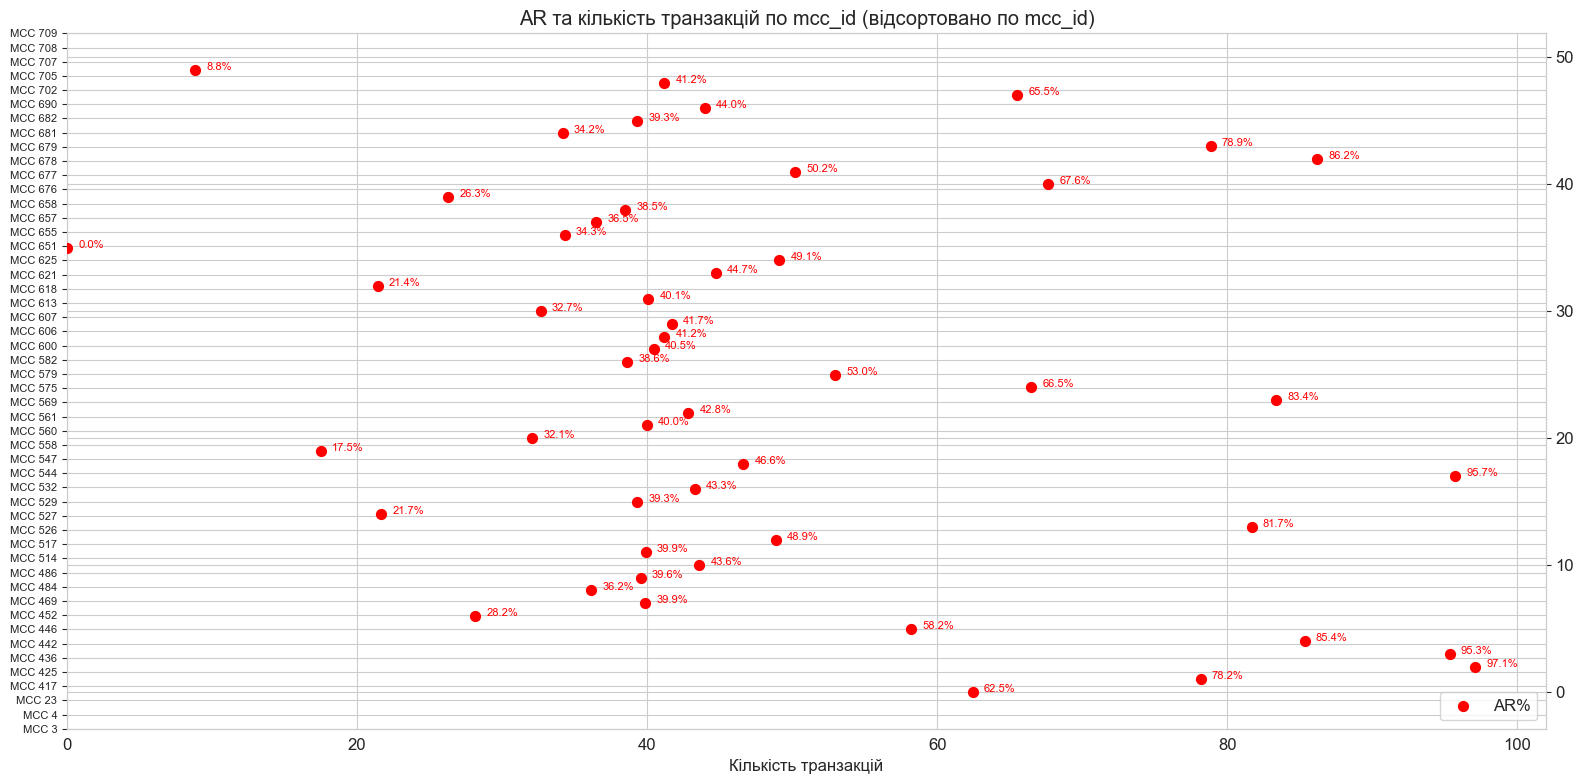

Унікальних mcc_id: 63

Top-5 mcc_id по AR (min 1000 транзакцій):
 mcc_id       ar  count
   23.0 0.971077   3492
  532.0 0.957258  32544
  417.0 0.953264 111242
  681.0 0.862054   6807
  425.0 0.853518   2601

Bottom-5 mcc_id по AR (min 1000 транзакцій):
 mcc_id       ar  count
  709.0 0.088423   1097
  547.0 0.175214   5713
  621.0 0.214118  47259
  526.0 0.216645   1574
  442.0 0.281670   2084


In [62]:
# AR по mcc_id
mcc_stats = train.groupby('mcc_id')['is_success'].agg(['mean', 'count']).reset_index()
mcc_stats.columns = ['mcc_id', 'ar', 'count']
mcc_stats = mcc_stats[mcc_stats['count'] >= 100].sort_values('mcc_id')

fig, ax1 = plt.subplots(figsize=(16, 8))
ax2 = ax1.twinx()

y = range(len(mcc_stats))
# ax1.barh(y, mcc_stats['count'], color='lightblue', alpha=0.7, label='Кількість')
ax2.barh(y, mcc_stats['ar'] * 100, color='red', alpha=0.0)  # invisible, just to set scale
ax2.scatter(mcc_stats['ar'] * 100, y, color='red', s=50, zorder=5, label='AR%')
for yi, ar in zip(y, mcc_stats['ar'] * 100):
    ax2.annotate(f'{ar:.1f}%', (ar, yi), textcoords='offset points', xytext=(8, 0), fontsize=8, color='red')

ax1.set_yticks(y)
ax1.set_yticklabels([f"MCC {int(m)}" for m in mcc_stats['mcc_id']], fontsize=8)
ax1.set_xlabel('Кількість транзакцій')
ax2.set_xlabel('AR (%)')
ax1.set_title('AR та кількість транзакцій по mcc_id (відсортовано по mcc_id)')
ax1.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.tight_layout()
plt.show()

print(f"Унікальних mcc_id: {train['mcc_id'].nunique()}")
print(f"\nTop-5 mcc_id по AR (min 1000 транзакцій):")
top_mcc = mcc_stats[mcc_stats['count'] >= 1000].nlargest(5, 'ar')
print(top_mcc[['mcc_id', 'ar', 'count']].to_string(index=False))
print(f"\nBottom-5 mcc_id по AR (min 1000 транзакцій):")
bot_mcc = mcc_stats[mcc_stats['count'] >= 1000].nsmallest(5, 'ar')
print(bot_mcc[['mcc_id', 'ar', 'count']].to_string(index=False))

## 11. Картковий аналіз (Card Analysis)

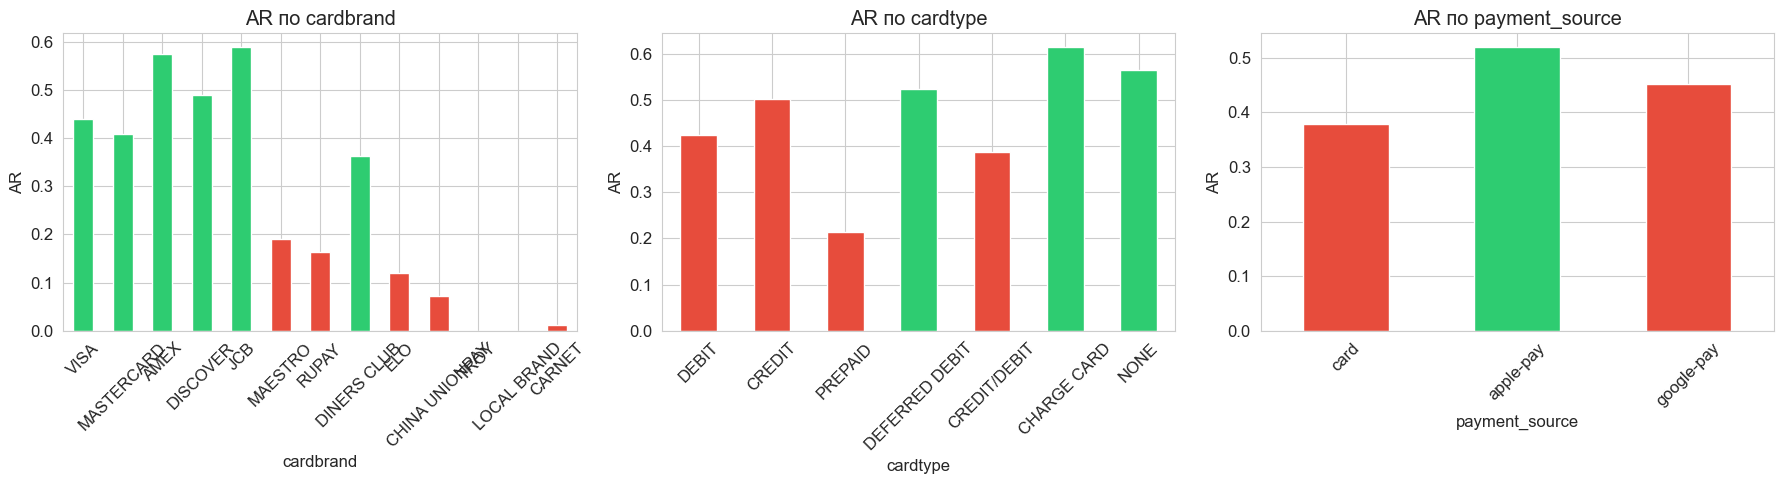

In [25]:
# AR по cardbrand, cardtype, payment_source
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['cardbrand', 'cardtype', 'payment_source']):
    if col not in train.columns:
        continue
    stats = train.groupby(col)['is_success'].agg(['mean', 'count']).sort_values('count', ascending=False)
    stats = stats[stats['count'] >= 100]
    
    colors = ['#2ecc71' if v > stats['mean'].median() else '#e74c3c' for v in stats['mean']]
    stats['mean'].plot.bar(ax=axes[i], color=colors)
    axes[i].set_title(f'AR по {col}')
    axes[i].set_ylabel('AR')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

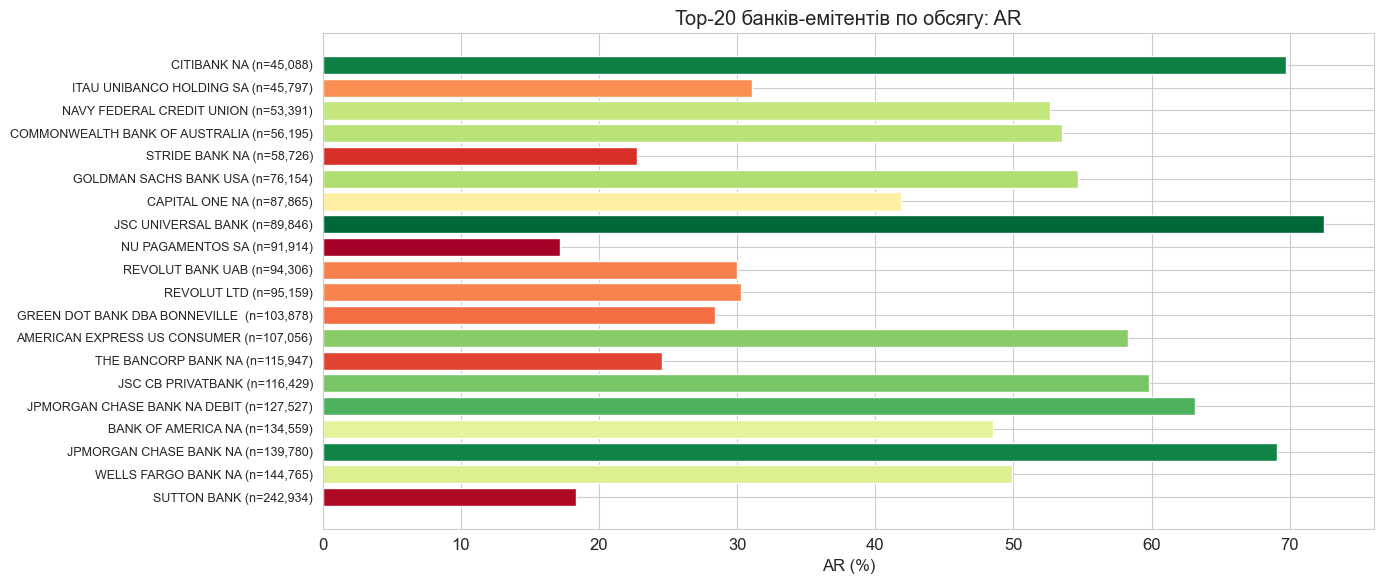

Унікальних банків-емітентів: 10558


In [26]:
# Top банків-емітентів по AR
bank_stats = train.groupby('bank')['is_success'].agg(['mean', 'count']).sort_values('count', ascending=False)
bank_stats.columns = ['ar', 'count']
top_banks = bank_stats.head(20)

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.RdYlGn((top_banks['ar'] - top_banks['ar'].min()) / (top_banks['ar'].max() - top_banks['ar'].min() + 1e-9))
ax.barh(range(len(top_banks)), top_banks['ar'] * 100, color=colors)
ax.set_yticks(range(len(top_banks)))
ax.set_yticklabels([f"{b[:30]} (n={int(c):,})" for b, c in zip(top_banks.index, top_banks['count'])], fontsize=9)
ax.set_xlabel('AR (%)')
ax.set_title('Top-20 банків-емітентів по обсягу: AR')
plt.tight_layout()
plt.show()

print(f"Унікальних банків-емітентів: {train['bank'].nunique()}")

## 12. Аналіз суми транзакцій (Amount)

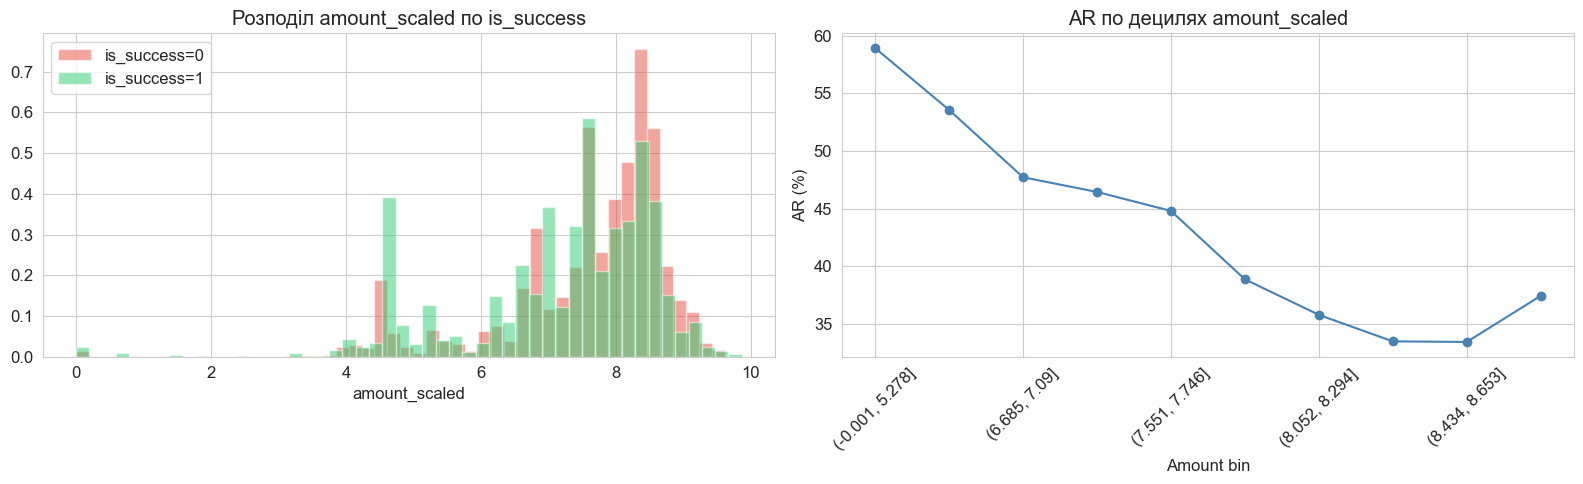

In [27]:
# Розподіл amount_scaled по таргету
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Гістограма
for label, color in [(0, '#e74c3c'), (1, '#2ecc71')]:
    subset = train[train['is_success'] == label]['amount_scaled'].dropna()
    subset = subset[subset < subset.quantile(0.99)]  # прибрати екстремальні викиди
    axes[0].hist(subset, bins=50, alpha=0.5, color=color, label=f'is_success={label}', density=True)
axes[0].set_title('Розподіл amount_scaled по is_success')
axes[0].set_xlabel('amount_scaled')
axes[0].legend()

# AR по квантилях суми
train['amount_bin'] = pd.qcut(train['amount_scaled'].dropna(), q=10, duplicates='drop')
amount_ar = train.groupby('amount_bin', observed=True)['is_success'].mean() * 100
amount_ar.plot(ax=axes[1], marker='o', color='steelblue')
axes[1].set_title('AR по децилях amount_scaled')
axes[1].set_ylabel('AR (%)')
axes[1].set_xlabel('Amount bin')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

train.drop(columns=['amount_bin'], inplace=True)

## 13. 3D-Secure та антифрод

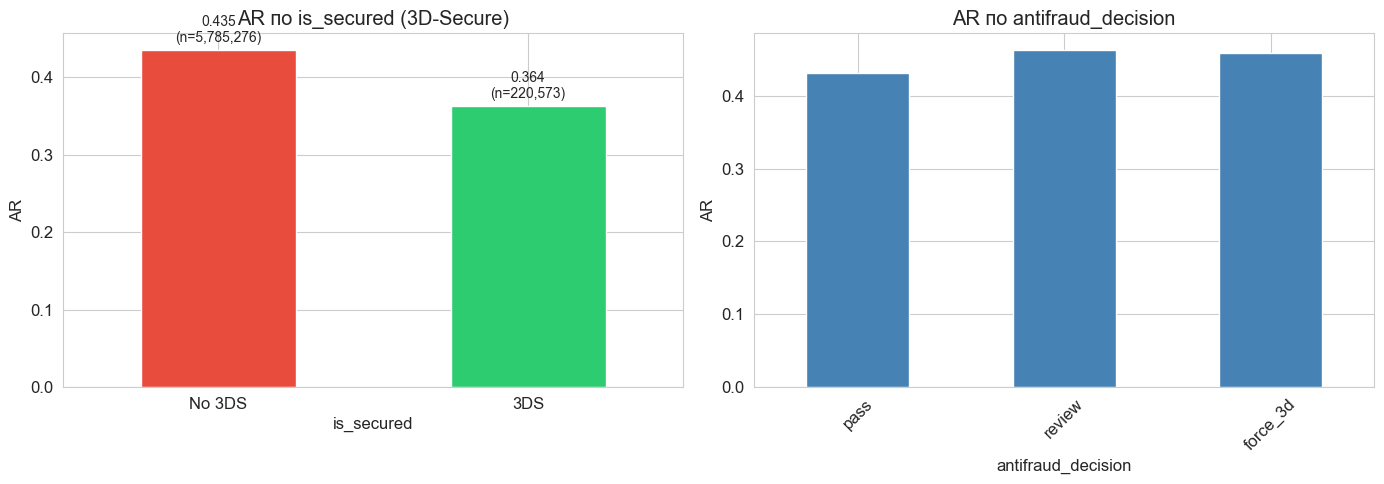

In [28]:
# AR по is_secured та antifraud_decision
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# is_secured
sec_ar = train.groupby('is_secured')['is_success'].agg(['mean', 'count'])
sec_ar['mean'].plot.bar(ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('AR по is_secured (3D-Secure)')
axes[0].set_ylabel('AR')
axes[0].set_xticklabels(['No 3DS', '3DS'], rotation=0)
for idx, (val, cnt) in enumerate(zip(sec_ar['mean'], sec_ar['count'])):
    axes[0].text(idx, val + 0.01, f'{val:.3f}\n(n={int(cnt):,})', ha='center', fontsize=10)

# antifraud_decision
af_ar = train.groupby('antifraud_decision')['is_success'].agg(['mean', 'count']).sort_values('count', ascending=False)
af_ar['mean'].plot.bar(ax=axes[1], color='steelblue')
axes[1].set_title('AR по antifraud_decision')
axes[1].set_ylabel('AR')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 14. Термін дії картки (card_exp_relative_scaled)

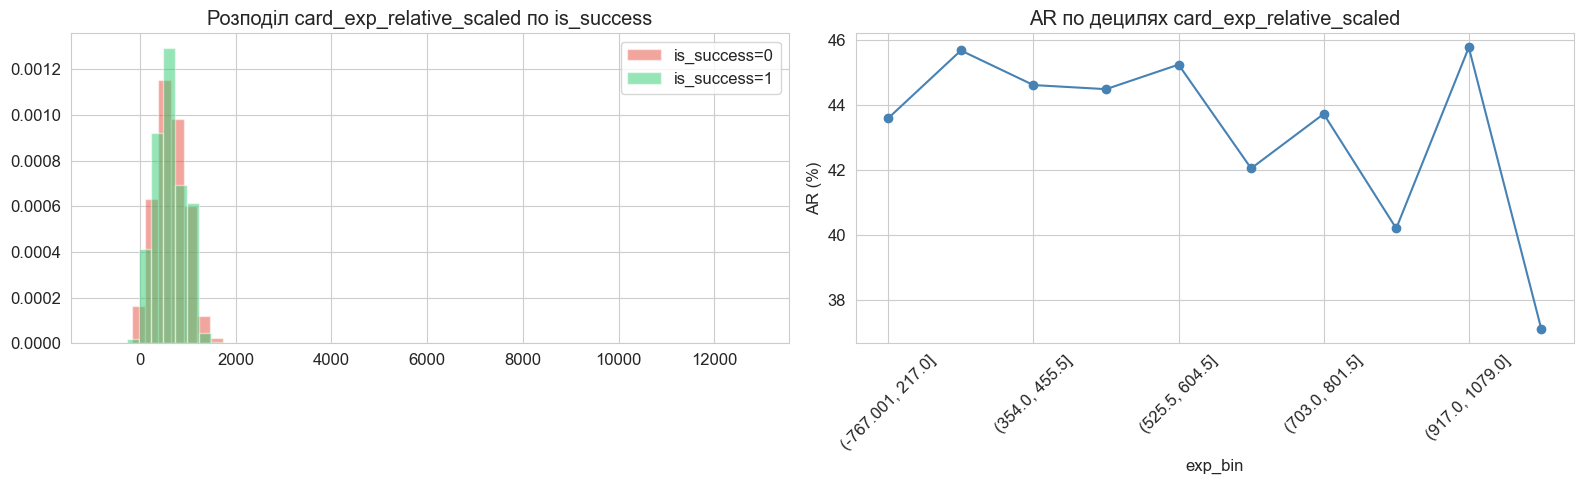

In [29]:
# card_exp_relative_scaled vs is_success
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for label, color in [(0, '#e74c3c'), (1, '#2ecc71')]:
    subset = train[train['is_success'] == label]['card_exp_relative_scaled'].dropna()
    axes[0].hist(subset, bins=50, alpha=0.5, color=color, label=f'is_success={label}', density=True)
axes[0].set_title('Розподіл card_exp_relative_scaled по is_success')
axes[0].legend()

# AR по бінах card_exp
train['exp_bin'] = pd.qcut(train['card_exp_relative_scaled'].dropna(), q=10, duplicates='drop')
exp_ar = train.groupby('exp_bin', observed=True)['is_success'].mean() * 100
exp_ar.plot(ax=axes[1], marker='o', color='steelblue')
axes[1].set_title('AR по децилях card_exp_relative_scaled')
axes[1].set_ylabel('AR (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

train.drop(columns=['exp_bin'], inplace=True)

## 15. Train vs Test — перевірка розподілів

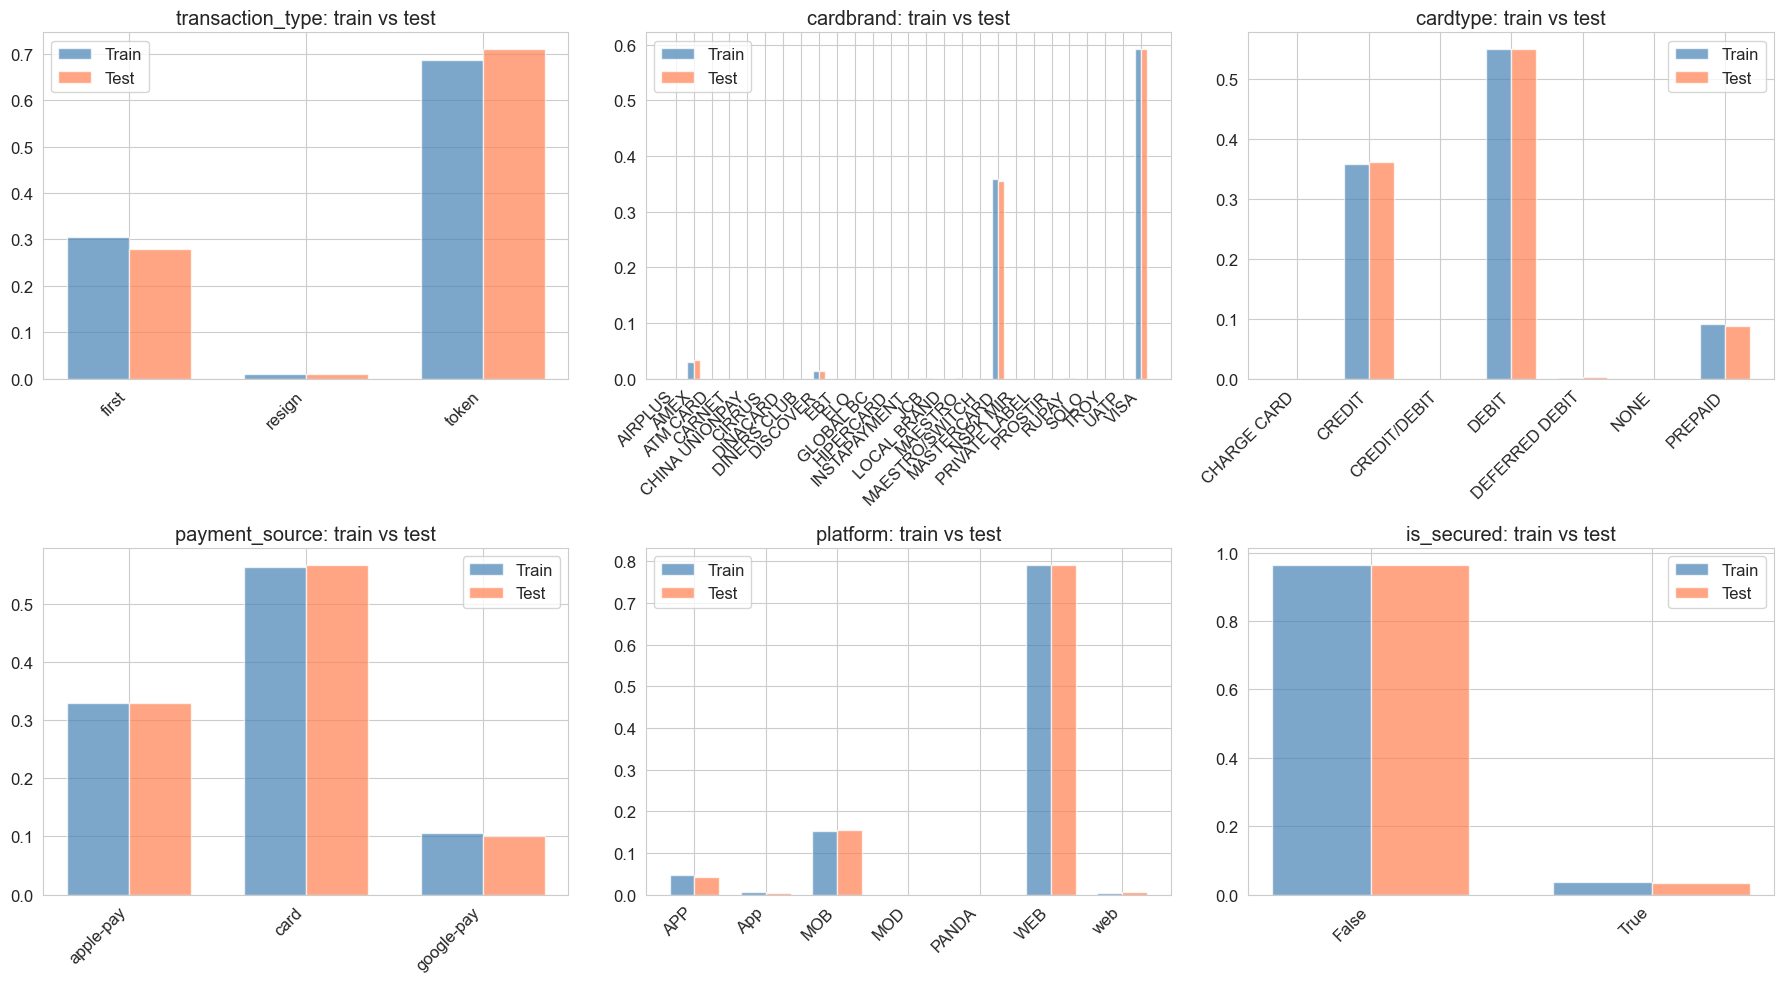

In [30]:
# Порівняння розподілів ключових ознак train vs test
compare_cols = ['transaction_type', 'cardbrand', 'cardtype', 'payment_source', 'platform', 'is_secured']
compare_cols = [c for c in compare_cols if c in train.columns and c in test.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(compare_cols):
    if i >= len(axes):
        break
    train_dist = train[col].value_counts(normalize=True).sort_index()
    test_dist = test[col].value_counts(normalize=True).sort_index()
    
    all_vals = sorted(set(train_dist.index) | set(test_dist.index))
    x = range(len(all_vals))
    
    train_vals = [train_dist.get(v, 0) for v in all_vals]
    test_vals = [test_dist.get(v, 0) for v in all_vals]
    
    width = 0.35
    axes[i].bar([xi - width/2 for xi in x], train_vals, width, label='Train', alpha=0.7, color='steelblue')
    axes[i].bar([xi + width/2 for xi in x], test_vals, width, label='Test', alpha=0.7, color='coral')
    axes[i].set_xticks(list(x))
    axes[i].set_xticklabels([str(v)[:15] for v in all_vals], rotation=45, ha='right')
    axes[i].set_title(f'{col}: train vs test')
    axes[i].legend()

for j in range(len(compare_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

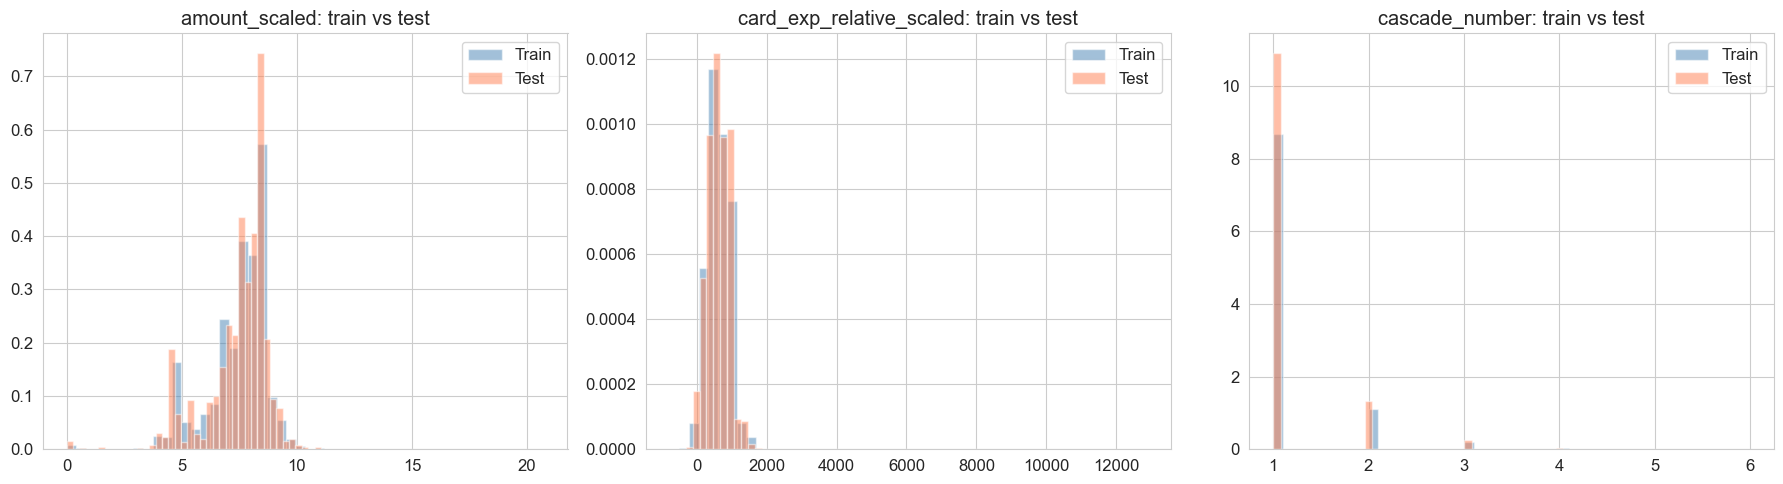

In [31]:
# Порівняння числових розподілів train vs test
num_compare = ['amount_scaled', 'card_exp_relative_scaled', 'cascade_number']
num_compare = [c for c in num_compare if c in train.columns and c in test.columns]

fig, axes = plt.subplots(1, len(num_compare), figsize=(6 * len(num_compare), 5))
if len(num_compare) == 1:
    axes = [axes]

for i, col in enumerate(num_compare):
    train[col].dropna().hist(bins=50, ax=axes[i], alpha=0.5, color='steelblue', label='Train', density=True)
    test[col].dropna().hist(bins=50, ax=axes[i], alpha=0.5, color='coral', label='Test', density=True)
    axes[i].set_title(f'{col}: train vs test')
    axes[i].legend()

plt.tight_layout()
plt.show()

## 16. Data Leakage — перевірка `error_code`

`error_code` може бути leakage-ознакою, бо присвоюється після результату транзакції.

In [32]:
# Перевірка error_code на leakage
print("AR по наявності error_code:")
train['has_error_code'] = train['error_code'].notna()
print(train.groupby('has_error_code')['is_success'].agg(['mean', 'count']))

print(f"\n% success серед тих, хто має error_code: {train[train['has_error_code']]['is_success'].mean()*100:.2f}%")
print(f"% success серед тих, хто НЕ має error_code: {train[~train['has_error_code']]['is_success'].mean()*100:.2f}%")

# Чи є error_code в тесті?
print(f"\nПропуски error_code в test: {test['error_code'].isna().sum()} ({test['error_code'].isna().mean()*100:.1f}%)")

train.drop(columns=['has_error_code'], inplace=True)

AR по наявності error_code:
                    mean    count
has_error_code                   
False           0.995997  2608484
True            0.000000  3397365

% success серед тих, хто має error_code: 0.00%
% success серед тих, хто НЕ має error_code: 99.60%

Пропуски error_code в test: 294463 (44.1%)


## Decision Tree — автоматичний пошук правил що впливають на AR

Загальний fail rate: 56.74%
Загальний AR: 43.26%

1. DECISION TREE — автоматичний пошук правил (TX-level)

--- Depth=3 (accuracy=0.6752) ---

--- Depth=5 (accuracy=0.6867) ---

Дерево рішень (depth=5):
|--- merchant_token_type_recurring <= 0.50
|   |--- cascade_number <= 1.50
|   |   |--- card_pan_type_pan <= 0.50
|   |   |   |--- transaction_type_first <= 0.50
|   |   |   |   |--- platform_APP <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- platform_APP >  0.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- transaction_type_first >  0.50
|   |   |   |   |--- ip_country_top_BRA <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- ip_country_top_BRA >  0.50
|   |   |   |   |   |--- class: 1
|   |   |--- card_pan_type_pan >  0.50
|   |   |   |--- platform_APP <= 0.50
|   |   |   |   |--- ip_country_top_UKR <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- ip_country_top_UKR >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- platform_APP >

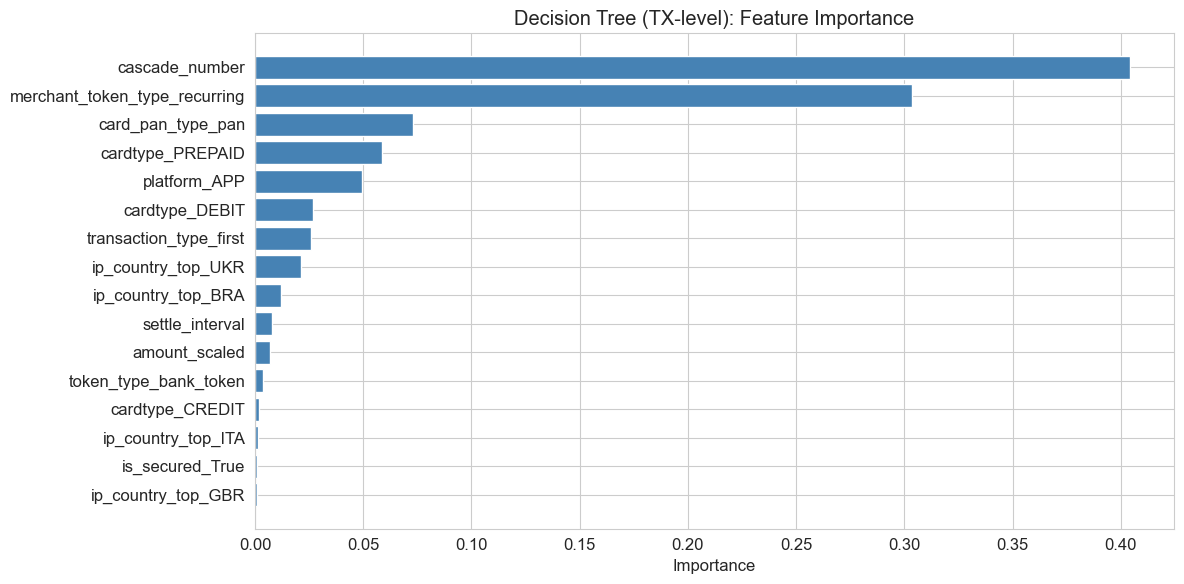

In [2]:
from sklearn.tree import DecisionTreeClassifier, export_text

overall_fail = 1 - train['is_success'].mean()
print(f"Загальний fail rate: {overall_fail:.2%}")
print(f"Загальний AR: {train['is_success'].mean():.2%}")

# =============================================================================
# 1. DECISION TREE на рівні транзакцій
# =============================================================================
print(f"\n{'='*90}")
print("1. DECISION TREE — автоматичний пошук правил (TX-level)")
print(f"{'='*90}")

cat_cols = ['transaction_type', 'merchant_token_type', 'platform',
            'is_subscription', 'is_secured', 'token_type', 'cardbrand',
            'cardtype', 'card_pan_type', 'payment_source', 'is_payfac',
            'antifraud_decision']
num_cols = ['amount_scaled', 'card_exp_relative_scaled', 'cascade_number', 'settle_interval']

# Топ-20 країн (інакше занадто багато dummy)
top_countries = train['ip_country'].value_counts().head(20).index
train['ip_country_top'] = train['ip_country'].where(train['ip_country'].isin(top_countries), 'OTHER')
cat_cols_tree = cat_cols + ['ip_country_top']

df_tree = train[cat_cols_tree + num_cols + ['is_success']].copy()
df_tree[num_cols] = df_tree[num_cols].fillna(-1)
df_tree[cat_cols_tree] = df_tree[cat_cols_tree].fillna('MISSING')

df_encoded = pd.get_dummies(df_tree, columns=cat_cols_tree, drop_first=False)
feature_names = [c for c in df_encoded.columns if c != 'is_success']
X = df_encoded[feature_names].values
y = (df_encoded['is_success'] == 0).astype(int).values  # predict fail

# Дерево з різною глибиною
for depth in [3, 5]:
    dt = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=1000, random_state=42)
    dt.fit(X, y)
    print(f"\n--- Depth={depth} (accuracy={dt.score(X, y):.4f}) ---")

# Основне дерево depth=5
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=1000, random_state=42)
dt.fit(X, y)

tree_rules = export_text(dt, feature_names=feature_names, max_depth=5)
print(f"\nДерево рішень (depth=5):")
print(tree_rules[:4000])

# Feature importance
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nТоп-20 фіч за важливістю:")
for _, row in feat_imp.head(20).iterrows():
    if row['importance'] > 0.001:
        bar = '█' * int(row['importance'] * 100)
        print(f"  {row['feature']:40s} {row['importance']:.4f} {bar}")

# Візуалізація feature importance
fig, ax = plt.subplots(figsize=(12, 6))
top_feat = feat_imp[feat_imp['importance'] > 0.001].head(20)
ax.barh(top_feat['feature'], top_feat['importance'], color='steelblue', edgecolor='white')
ax.set_xlabel('Importance')
ax.set_title('Decision Tree (TX-level): Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

train.drop(columns=['ip_country_top'], inplace=True)

2. RULE MINING — бінарні умови з найвищим lift

Топ-20 одиночних умов по lift (fail rate):
Правило                                              TX   Fail%     AR%   Lift
--------------------------------------------------------------------------------
cardbrand=TROY                                      747 100.0%   0.0%   1.76
cardbrand=CHINA UNIONPAY                            761  92.8%   7.2%   1.64
cascade_number>=3                               138,722  89.9%  10.1%   1.58
cardbrand=ELO                                     1,125  88.0%  12.0%   1.55
cascade_number>=2                               782,865  87.2%  12.8%   1.54
cardbrand=RUPAY                                   4,608  83.6%  16.4%   1.47
transaction_type=resign                          55,343  81.8%  18.2%   1.44
cardbrand=MAESTRO                                 6,305  81.0%  19.0%   1.43
cardtype=PREPAID                                542,591  78.7%  21.3%   1.39
platform=web                                     25,669 

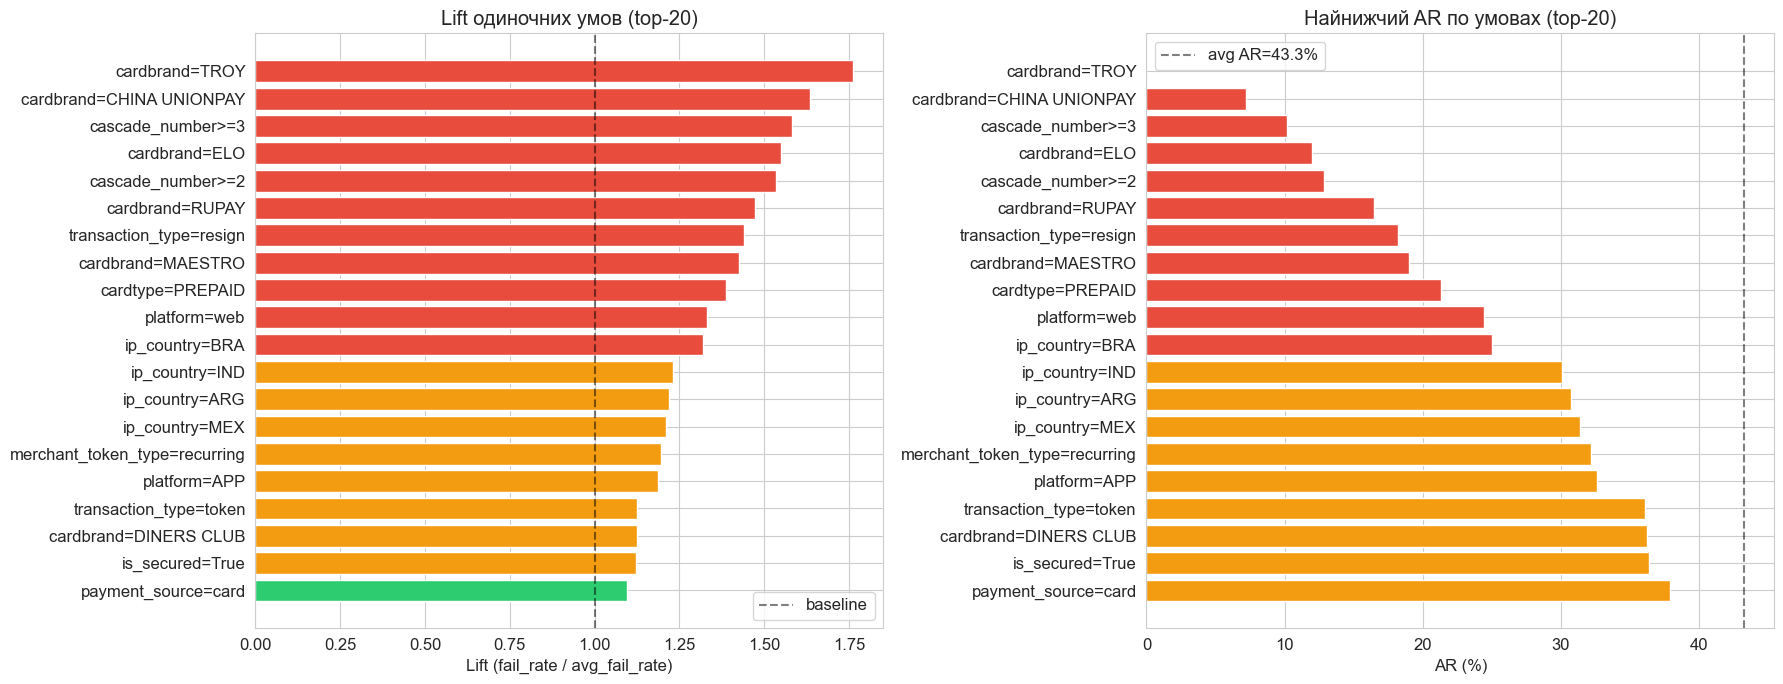

In [3]:
# =============================================================================
# 2. RULE MINING — бінарні умови з найвищим lift над загальним fail rate
# =============================================================================
print(f"{'='*90}")
print("2. RULE MINING — бінарні умови з найвищим lift")
print(f"{'='*90}")

overall_fail = 1 - train['is_success'].mean()
conditions = {}

# Категоріальні
for col in ['transaction_type', 'merchant_token_type', 'platform', 'cardbrand',
            'cardtype', 'payment_source', 'card_pan_type', 'antifraud_decision']:
    for val in train[col].dropna().unique():
        n = (train[col] == val).sum()
        if n >= 500:
            conditions[f'{col}={val}'] = train[col] == val

# Булеві
for col in ['is_subscription', 'is_secured', 'is_payfac']:
    for val in [True, False]:
        conditions[f'{col}={val}'] = train[col] == val

# Числові пороги
conditions['amount_scaled<1'] = train['amount_scaled'] < 1
conditions['amount_scaled<5'] = train['amount_scaled'] < 5
conditions['amount_scaled>500'] = train['amount_scaled'] > 500
conditions['amount_scaled>1000'] = train['amount_scaled'] > 1000
conditions['cascade_number>=2'] = train['cascade_number'] >= 2
conditions['cascade_number>=3'] = train['cascade_number'] >= 3
conditions['card_exp_scaled<30'] = train['card_exp_relative_scaled'] < 30
conditions['card_exp_scaled<0'] = train['card_exp_relative_scaled'] < 0
conditions['country_mismatch'] = train['ip_country'] != train['card_country']
conditions['country_match'] = train['ip_country'] == train['card_country']

# Топ країн
for country in train['ip_country'].value_counts().head(15).index:
    conditions[f'ip_country={country}'] = train['ip_country'] == country

# Одиночні правила
single_rules = []
for name, mask in conditions.items():
    subset = train[mask]
    if len(subset) < 500:
        continue
    fail_rate = 1 - subset['is_success'].mean()
    lift = fail_rate / overall_fail if overall_fail > 0 else 0
    single_rules.append({
        'rule': name,
        'count': len(subset),
        'fail_rate': fail_rate,
        'ar': subset['is_success'].mean(),
        'lift': lift
    })

single_df = pd.DataFrame(single_rules).sort_values('lift', ascending=False)
print(f"\nТоп-20 одиночних умов по lift (fail rate):")
print(f"{'Правило':<45} {'TX':>9} {'Fail%':>7} {'AR%':>7} {'Lift':>6}")
print('-' * 80)
for _, r in single_df.head(20).iterrows():
    print(f"{r['rule']:<45} {int(r['count']):>9,} {r['fail_rate']:>6.1%} {r['ar']:>6.1%} {r['lift']:>6.2f}")

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Lift одиночних умов
top_s = single_df.head(20)
colors = ['#e74c3c' if l > 1.3 else '#f39c12' if l > 1.1 else '#2ecc71' for l in top_s['lift']]
axes[0].barh(top_s['rule'], top_s['lift'], color=colors, edgecolor='white')
axes[0].axvline(1.0, color='black', ls='--', alpha=0.5, label='baseline')
axes[0].set_xlabel('Lift (fail_rate / avg_fail_rate)')
axes[0].set_title('Lift одиночних умов (top-20)')
axes[0].invert_yaxis()
axes[0].legend()

# AR одиночних умов
top_ar = single_df.sort_values('ar').head(20)
colors_ar = ['#e74c3c' if a < 0.3 else '#f39c12' if a < 0.4 else '#2ecc71' for a in top_ar['ar']]
axes[1].barh(top_ar['rule'], top_ar['ar'] * 100, color=colors_ar, edgecolor='white')
axes[1].axvline(train['is_success'].mean() * 100, color='black', ls='--', alpha=0.5, label=f'avg AR={train["is_success"].mean()*100:.1f}%')
axes[1].set_xlabel('AR (%)')
axes[1].set_title('Найнижчий AR по умовах (top-20)')
axes[1].invert_yaxis()
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
# =============================================================================
# 3. DECISION TREE НА РІВНІ ЮЗЕРІВ
# =============================================================================
print(f"{'='*90}")
print("3. DECISION TREE НА РІВНІ ЮЗЕРІВ (customer_account_id)")
print(f"{'='*90}")

# Побудова user-level фіч
user_f = train.dropna(subset=['customer_account_id']).groupby('customer_account_id').agg(
    tx_count=('psp_order_id', 'count'),
    fail_rate=('is_success', lambda x: 1 - x.mean()),
    ar=('is_success', 'mean'),
    fail_count=('is_success', lambda x: (x == 0).sum()),
    success_count=('is_success', 'sum'),
    mean_amount=('amount_scaled', 'mean'),
    std_amount=('amount_scaled', 'std'),
    min_amount=('amount_scaled', 'min'),
    max_amount=('amount_scaled', 'max'),
    n_ip_countries=('ip_country', 'nunique'),
    n_card_countries=('card_country', 'nunique'),
    n_shops=('shop_id', 'nunique'),
    n_psp=('psp_id', 'nunique'),
    n_currencies=('currency', 'nunique'),
    n_cardbrands=('cardbrand', 'nunique'),
    recurring_ratio=('transaction_type', lambda x: (x == 'token').mean()),
    secured_rate=('is_secured', 'mean'),
    subscription_rate=('is_subscription', 'mean'),
    mean_cascade=('cascade_number', 'mean'),
    max_cascade=('cascade_number', 'max'),
    mean_card_exp=('card_exp_relative_scaled', 'mean'),
    ip_card_mismatch=('psp_order_id', lambda x: (
        train.loc[x.index, 'ip_country'] != train.loc[x.index, 'card_country']
    ).mean()),
    top_ip=('ip_country', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'unknown'),
    top_platform=('platform', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'unknown'),
    top_cardbrand=('cardbrand', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'unknown'),
    top_cardtype=('cardtype', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'unknown'),
    top_payment_source=('payment_source', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'unknown'),
    top_tx_type=('transaction_type', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'unknown'),
).reset_index()

user_f['std_amount'] = user_f['std_amount'].fillna(0)
user_f['amount_range'] = user_f['max_amount'] - user_f['min_amount']

# Тільки юзери з >1 TX
multi_u = user_f[user_f['tx_count'] > 1].copy().reset_index(drop=True)
multi_u['is_full_fail'] = (multi_u['ar'] == 0).astype(int)

print(f"Юзерів з >1 TX: {len(multi_u):,}")
print(f"Юзерів з 100% fail: {multi_u['is_full_fail'].sum():,} ({multi_u['is_full_fail'].mean():.2%})")

# Числові фічі для дерева
num_features = ['tx_count', 'mean_amount', 'std_amount', 'amount_range',
                'min_amount', 'max_amount', 'n_ip_countries', 'n_card_countries',
                'n_shops', 'n_psp', 'n_currencies', 'n_cardbrands',
                'recurring_ratio', 'secured_rate', 'subscription_rate',
                'mean_cascade', 'max_cascade', 'mean_card_exp', 'ip_card_mismatch']

cat_features_u = ['top_ip', 'top_platform', 'top_cardbrand', 'top_cardtype',
                  'top_payment_source', 'top_tx_type']

df_tree_u = multi_u[num_features + cat_features_u + ['is_full_fail']].copy()
df_enc_u = pd.get_dummies(df_tree_u, columns=cat_features_u, drop_first=False)
feat_names_u = [c for c in df_enc_u.columns if c != 'is_full_fail']

X_u = df_enc_u[feat_names_u].fillna(0).values
y_u = df_enc_u['is_full_fail'].values

dt_u = DecisionTreeClassifier(max_depth=6, min_samples_leaf=200, random_state=42)
dt_u.fit(X_u, y_u)
print(f"\nAccuracy: {dt_u.score(X_u, y_u):.4f}")

tree_text_u = export_text(dt_u, feature_names=feat_names_u, max_depth=6)
print(f"\nДерево рішень (user-level, depth=6):")
print(tree_text_u[:4000])

# Feature importance
feat_imp_u = pd.DataFrame({
    'feature': feat_names_u,
    'importance': dt_u.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nТоп-20 фіч за важливістю:")
for _, row in feat_imp_u.head(20).iterrows():
    if row['importance'] > 0.001:
        bar = '█' * int(row['importance'] * 100)
        print(f"  {row['feature']:40s} {row['importance']:.4f} {bar}")

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Feature importance
top_feat_u = feat_imp_u[feat_imp_u['importance'] > 0.001].head(20)
axes[0].barh(top_feat_u['feature'], top_feat_u['importance'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Importance')
axes[0].set_title('User-level Decision Tree: Feature Importance')
axes[0].invert_yaxis()

# User-level: розподіл fail_rate
axes[1].hist(multi_u['ar'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title(f'Розподіл AR по юзерах (n={len(multi_u):,})')
axes[1].set_xlabel('AR')
axes[1].set_ylabel('Кількість юзерів')
axes[1].axvline(multi_u['ar'].mean(), color='red', ls='--', label=f'mean={multi_u["ar"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

3. DECISION TREE НА РІВНІ ЮЗЕРІВ (customer_account_id)


KeyboardInterrupt: 

In [1]:
train['customer_account_id'].isna()

NameError: name 'train' is not defined

In [1]:
print('k')

k


## 17. Підсумки та рекомендації для моделювання

In [33]:
# Підсумкова таблиця ознак
feature_summary = []
for col in train.columns:
    if col in ['is_success', 'hour', 'dayofweek', 'day', 'date', 'is_cross_border']:
        continue
    feature_summary.append({
        'feature': col,
        'dtype': str(train[col].dtype),
        'nunique': train[col].nunique(),
        'missing_%': round(train[col].isna().mean() * 100, 2),
        'in_test': col in test.columns
    })

summary_df = pd.DataFrame(feature_summary)
print("Підсумкова таблиця ознак:")
summary_df

Підсумкова таблиця ознак:


,feature,dtype,nunique,missing_%,in_test
0,psp_order_id,str,6005849,0.00,True
1,order_id,str,5897762,0.00,True
2,customer_account_id,str,4221797,5.77,True
3,shop_id,int64,975,0.00,True
4,order_created_at,datetime64[us],2944991,0.00,True
5,transaction_type,str,3,0.00,True
6,merchant_token_type,str,3,31.37,True
7,traffic_source,str,14588,77.48,True
8,settle_interval,float64,28,17.23,True
9,antifraud_decision,str,3,0.00,True


In [40]:
test_1 = test[['psp_order_id' , 'error_code']].copy()
test_1

,psp_order_id,error_code
0,1317034493699c1ac6898c5,3.02.2
1,1317034507699c1ac789bfa,NaN
2,1317034508699c1ac889de6,3.08
3,1317034508699c1ac98a2cd,3.08
4,1317034542699c1aca8a5b6,NaN
...,...,...
667312,132809277269a3817a1c77a,NaN
667313,132809277069a3817a1c753,3.08
667314,132809276069a3817a1c81f,NaN
667315,132809279369a3817e1d6ff,3.02


### Ключові спостереження та рекомендації:

**Дані:**
- Train: ~6M рядків, Test: ~667K рядків
- Train та Test розділені по часу (хронологічний спліт)
- Одне замовлення (`order_id`) може мати кілька спроб (`psp_order_id`) — ефект каскадування

**Потенційний leakage:**
- `error_code` — може бути наслідком результату транзакції, а не причиною. Перевірити чи є в тесті
- Хешовані ID-поля (`psp_order_id`, `order_id`, `customer_account_id`) — не використовувати як фічі напряму

**Важливі ознаки для моделі:**
- `cascade_number` — AR суттєво падає з кожною наступною спробою
- `transaction_type`, `merchant_token_type` — сильна різниця AR між типами
- `cardbrand`, `cardtype`, `payment_source` — різний AR для різних платіжних систем
- `is_secured` (3D-Secure) — впливає на AR
- `amount_scaled` — нелінійна залежність AR від суми
- `card_exp_relative_scaled` — термін дії картки корелює з AR
- `ip_country`, `card_country` — географія суттєво впливає
- `is_cross_border` (ip_country != card_country) — корисна інженерна ознака
- `psp_id`, `acquiring_bank_id` — різні провайдери мають різний AR
- Часові ознаки: година, день тижня

**Feature Engineering ідеї:**
- `is_cross_border` — чи збігається країна IP та картки
- Часові ознаки з `order_created_at` (hour, dayofweek, day)
- Агрегатні фічі: historical AR по `shop_id`, `bank`, `ip_country`, `psp_id`
- Кількість попередніх спроб для цього `order_id`
- Target encoding для високо-кардинальних категоріальних ознак